In [2]:
import os
import sys
import argparse
sys.path.append("..")
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from obspy import UTCDateTime, Stream
from tqdm import tqdm
import seaborn as sns
from obspy import read

plt.rcParams.update({
    'font.size': 7,             # Set global font size
    'font.family': 'Arial',      # Set global font family
    'legend.fontsize': 6,        # Set legend font size
    'figure.figsize': (5.5, 3.5), # Set figure size in inches
    'axes.formatter.limits': (-3, 6),
    'axes.formatter.use_mathtext': True,
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})
sns.set_context("notebook", font_scale=1)  # Ensures Seaborn uses updated fonts/sizes
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import ttest_ind_from_stats

from collections import Counter
import scipy.stats as stats

In [3]:
def plot_grouped_bar_with_error(data, x, y, hue, hue_order, ax,
                                palette="viridis", bar_width=0.35, ylim=None):
    """
    Plot grouped bar chart with mean and standard error using Matplotlib.

    Parameters:
    - data: pd.DataFrame
    - x: str, column for x-axis categories (e.g., "Interval")
    - y: str, column for y-axis values (e.g., "MSE_ts")
    - hue: str, column to split bars within each x (e.g., "Model")
    - hue_order: list of str, order of hue categories (e.g., ["LSTM", "xLSTM"])
    - ax: matplotlib.axes.Axes, axis to draw the plot on
    - palette: str or colormap, default "viridis"
    - bar_width: float, width of each bar
    """

    # Group data and compute mean and SE
    summary_df = data.groupby([x, hue]).agg(
        mean_y=(y, 'mean'),
        se_y=(y, lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    ).reset_index()

    x_labels = summary_df[x].unique()
    x_pos = np.arange(len(x_labels))
    cmap = ['yellowgreen', 'turquoise', 'indianred']

    for i, hue_val in enumerate(hue_order):
        subset = summary_df[summary_df[hue] == hue_val]
        offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
        xpos = x_pos + offset

        bars = ax.bar(
            xpos,
            subset['mean_y'],
            yerr=subset['se_y'],
            width=bar_width,
            label=hue_val,
            color=cmap[i],
            capsize=5,
            edgecolor='black'
        )

        # Annotate bars with height
        for j, bar in enumerate(bars):
            height = bar.get_height()
            err = float(subset['se_y'].iloc[j])
            y_point = height + err  # place annotation at top of yerr
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, y_point),
                        xytext=(0, 3),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=6, fontweight='bold')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.legend(title=hue)
    if ylim is not None:
        ax.set_ylim(ylim)
    # ax.set_title(f"Mean {y} by {x} and {hue}")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    return None    

# Peak Analysis

In [4]:
base_dir = f"../comparison_baseline_cv_5_15"
dir_dict = {i : f"{base_dir}_{i}/average_60_45" for i in range(1,4)}
# dir_dict[6] = "../comparison_baseline_5_1_15/average_30_20"
print(dir_dict)
df1 = pd.read_csv(f"{dir_dict[1]}/model_evaluation/best_combinations.csv")
df2 = pd.read_csv(f"{dir_dict[2]}/model_evaluation/best_combinations.csv")
df3 = pd.read_csv(f"{dir_dict[3]}/model_evaluation/best_combinations.csv")
for idx, df in enumerate([df1, df2, df3]):
    df.drop(columns=['RMSE', 'MAE', 'R2', 'Corr', 'PearsonR'], inplace=True)
    try:
        df.drop(columns=['ref_MSE'], inplace=True)
    except:
        pass
    df['Repeat'] = len(df) * [idx]
    # df = df[df['Config'] == 'v_larger']
for idy, df in enumerate([df1, df2, df3]):
    print(idy)
    peak_values, peak_values_true = [], []
    # df = df[df['Config'] == 'v_larger']
    for idx, row in df.iterrows():
        temp = pd.read_csv(f"{dir_dict[idy+1]}/output_df/{row['Config']}/{row['Interval']}/{row['Model']}_t{row['Test']}_v{row['Val']}.csv")
        peak_values.append(np.round(np.max(temp['Predicted_Output'].to_numpy()), 3))
        peak_values_true.append(np.round(np.max(temp['Output'].to_numpy()), 3))
    df['True_Peak'] = peak_values_true
    df['Peak'] = peak_values
df = pd.concat([df1, df2, df3], axis=0)
df.head()

{1: '../comparison_baseline_cv_5_15_1/average_60_45', 2: '../comparison_baseline_cv_5_15_2/average_60_45', 3: '../comparison_baseline_cv_5_15_3/average_60_45'}
0
1
2


,Model,Config,Time_To_Train,Test,Val,Interval,MSE,Hist_WMSE,Repeat,True_Peak,Peak
0,xLSTM,default,0:25:46,161,232,5,2.9521,0.0963,0,11.243,12.058
1,xLSTM,default,0:22:17,172,207,5,3.0394,0.1358,0,37.168,34.837
2,xLSTM,default,0:15:51,182,223,5,2.6561,0.1433,0,25.334,25.240
3,xLSTM,default,0:28:34,183,182,5,7.7170,0.1516,0,15.323,24.804
4,xLSTM,default,0:19:36,196,161,5,2.7584,0.1036,0,12.840,15.495


In [5]:
df[(df['Model'] == 'xLSTM') & (df['Test'] == 161) & (df['Interval'] == 5)]

,Model,Config,Time_To_Train,Test,Val,Interval,MSE,Hist_WMSE,Repeat,True_Peak,Peak
0,xLSTM,default,0:25:46,161,232,5,2.9521,0.0963,0,11.243,12.058
24,xLSTM,v_larger,0:29:25,161,232,5,2.9037,0.0959,0,11.243,11.200
0,xLSTM,default,0:44:38,161,182,5,3.0655,0.1002,1,11.243,13.018
24,xLSTM,v_larger,0:26:00,161,196,5,2.8959,0.1160,1,11.243,11.762
0,xLSTM,default,0:21:20,161,232,5,3.1891,0.0993,2,11.243,11.683
24,xLSTM,v_larger,0:39:42,161,232,5,2.9335,0.1147,2,11.243,11.678


In [6]:
peak_summary = pd.DataFrame(columns=['Model', 'Test_Julday', 'Interval', 'True_Peak', 'Mean_Peak', 'Std_Peak'])
for model in ['LSTM', 'xLSTM']:
    for interval in [5, 15, 30]:
        for test_julday in [161, 172, 182, 196, 207, 223, 232]:
            temp = df[(df['Model'] == model) & (df['Test'] == test_julday) & (df['Interval'] == interval) & (df['Config'] == 'v_larger')]
            tp = temp.iloc[0, -2]
            peaks = temp.iloc[:,-1].to_numpy()
            mean_peaks = np.round(np.mean(peaks),3)
            std_peaks = np.round(np.std(peaks),3)
            peak_summary.loc[len(peak_summary)] = [model, test_julday, interval, tp, mean_peaks, std_peaks]
peak_summary

,Model,Test_Julday,Interval,True_Peak,Mean_Peak,Std_Peak
0,LSTM,161,5,11.243,12.556,0.562
1,LSTM,172,5,37.168,28.052,2.353
2,LSTM,182,5,25.334,26.542,1.621
3,LSTM,196,5,12.840,16.323,1.880
4,LSTM,207,5,21.699,21.910,1.245
5,LSTM,223,5,28.748,30.497,0.182
6,LSTM,232,5,16.663,17.861,1.444
7,LSTM,161,15,11.202,12.506,0.174
8,LSTM,172,15,37.010,28.711,0.242
9,LSTM,182,15,25.320,25.913,1.027


In [7]:
peak_summary['MAE_means'] = np.round(np.array([np.abs(i - j) for i, j in zip(peak_summary['True_Peak'], peak_summary['Mean_Peak'])]), 3)
peak_summary.head()

,Model,Test_Julday,Interval,True_Peak,Mean_Peak,Std_Peak,MAE_means
0,LSTM,161,5,11.243,12.556,0.562,1.313
1,LSTM,172,5,37.168,28.052,2.353,9.116
2,LSTM,182,5,25.334,26.542,1.621,1.208
3,LSTM,196,5,12.840,16.323,1.880,3.483
4,LSTM,207,5,21.699,21.910,1.245,0.211


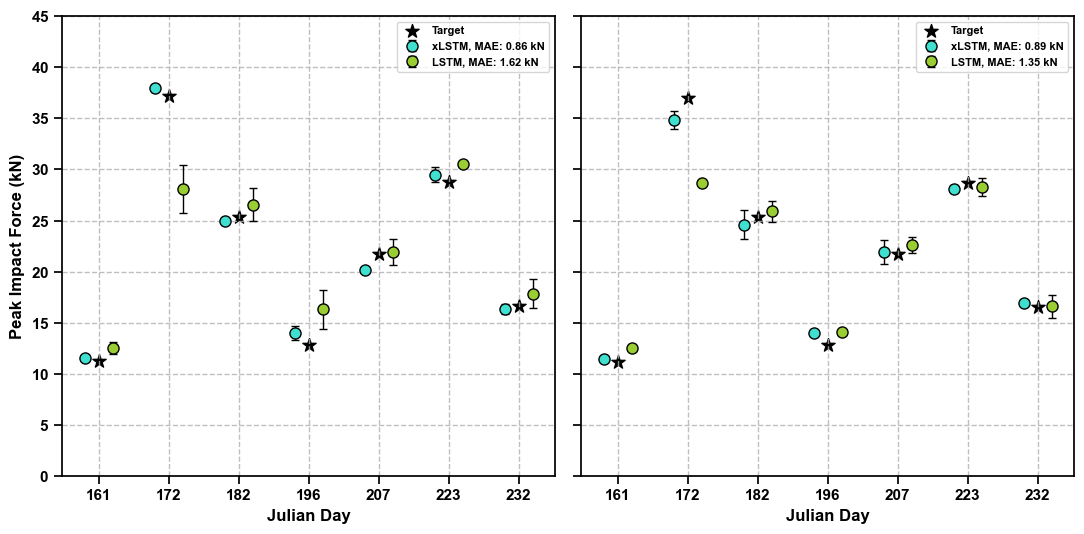

In [8]:
xticks = [161, 172, 182, 196, 207, 223, 232]
fig, ax = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
for axis in ax:
    axis.set_xticks(np.arange(1,8,1), xticks)
    axis.grid(True, linestyle="--", alpha=0.8)
    axis.set_xlabel("Julian Day");
    axis.set_ylim(0, 45)

ax[0].scatter(np.arange(1, 8, 1), peak_summary[
    (peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 5)
]['True_Peak'], s=100, label="Target", color='k', marker="*")
ax[0].errorbar(
    np.arange(0.8, 7.8, 1),
    peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 5)]['Mean_Peak'],
    yerr=peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 5)]['Std_Peak'],
    fmt='o',
    color='turquoise',
    label=f'xLSTM, MAE: {np.round(np.sqrt(np.mean(peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 5)]['MAE_means'])),2)} kN',
    markersize=8,
    markeredgecolor="k",
    capsize=3,
    elinewidth=1,
    ecolor='k'
)
ax[0].errorbar(
    np.arange(1.2, 8.2, 1),
    peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 5)]['Mean_Peak'],
    yerr=peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 5)]['Std_Peak'],
    fmt='o',
    color='yellowgreen',
    label=f'LSTM, MAE: {np.round(np.sqrt(np.mean(peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 5)]['MAE_means'])),2)} kN',
    markersize=8,
    markeredgecolor="k",
    capsize=3,
    elinewidth=1,
    ecolor='k'
)

ax[1].scatter(np.arange(1, 8, 1), peak_summary[
    (peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 15)
]['True_Peak'], s=100, label="Target", color='k', marker="*")
ax[1].errorbar(
    np.arange(0.8, 7.8, 1),
    peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 15)]['Mean_Peak'],
    yerr=peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 15)]['Std_Peak'],
    fmt='o',
    color='turquoise',
    label=f'xLSTM, MAE: {np.round(np.sqrt(np.mean(peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 15)]['MAE_means'])),2)} kN',
    markersize=8,
    markeredgecolor="k",
    capsize=3,
    elinewidth=1,
    ecolor='k'
)
ax[1].errorbar(
    np.arange(1.2, 8.2, 1),
    peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 15)]['Mean_Peak'],
    yerr=peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 15)]['Std_Peak'],
    fmt='o',
    color='yellowgreen',
    label=f'LSTM, MAE: {np.round(np.sqrt(np.mean(peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 15)]['MAE_means'])),2)} kN',
    markersize=8,
    markeredgecolor="k",
    capsize=3,
    elinewidth=1,
    ecolor='k'
)

# ax[2].scatter(np.arange(1, 8, 1), peak_summary[
#     (peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 30)
# ]['True_Peak'], s=35, label="Target", color='k', marker="*")
# ax[2].errorbar(
#     np.arange(0.8, 7.8, 1),
#     peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 30)]['Mean_Peak'],
#     yerr=peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 30)]['Std_Peak'],
#     fmt='o',
#     color='turquoise',
#     label=f'xLSTM, MAE: {np.round(np.sqrt(np.mean(peak_summary[(peak_summary['Model'] == 'xLSTM') & (peak_summary['Interval'] == 30)]['MAE_means'])),2)} kN',
#     markersize=6,
#     markeredgecolor="k",
#     capsize=3,
#     elinewidth=1,
#     ecolor='k'
# )
# ax[2].errorbar(
#     np.arange(1.2, 8.2, 1),
#     peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 30)]['Mean_Peak'],
#     yerr=peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 30)]['Std_Peak'],
#     fmt='o',
#     color='yellowgreen',
#     label=f'LSTM, MAE: {np.round(np.sqrt(np.mean(peak_summary[(peak_summary['Model'] == 'LSTM') & (peak_summary['Interval'] == 30)]['MAE_means'])),2)} kN',
#     markersize=6,
#     markeredgecolor="k",
#     capsize=3,
#     elinewidth=1,
#     ecolor='k'
# )

for axis in ax:
    axis.legend(fontsize=8)

ax[0].set_ylabel("Peak Impact Force (kN)");
# ax[0].text(0.05, 0.1, "(a)", transform=ax[0].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')
# ax[1].text(0.05, 0.1, "(b)", transform=ax[1].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')
# ax[2].text(0.05, 0.1, "(c)", transform=ax[2].transAxes, fontsize=12, fontweight="bold", va='top', ha='left')


fig.tight_layout()
fig.savefig("./output_images4/results/peak_comparison_larger.png", dpi=600)

# Effects of Model-Size  default-smaller on xLSTM

In [9]:
context_len = 5
sub_window_size = 5
file_name = "model_evaluation/evaluation_output_constrained.txt"
column_names = ['Model','Config','Time_To_Train','Test','Val','Interval','MSE','RMSE','MAE','R2','Corr','PearsonR','Hist-WMSE']
#########################################################
for smoothing in [0, 30, 60]:
    for divide_by in [1, 20, 45]:
        base_dir = f"../comparison_baseline_tt_5_15_1"
        df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                        names=column_names,
                        ).drop(0, axis=0).reset_index(inplace=False, drop=True)
        df1['Interval'] = df1['Interval'].astype(int)
        df1['MSE'] = df1['MSE'].astype(float)
        df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM')]
        df1['Repeat'] = [1] * len(df1)
        df = df1
        base_dir = f"../comparison_baseline_tt_5_15_2"
        df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                        names=column_names,
                        ).drop(0, axis=0).reset_index(inplace=False, drop=True)
        df1['Interval'] = df1['Interval'].astype(int)
        df1['MSE'] = df1['MSE'].astype(float)
        df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM')]
        df1['Repeat'] = [2] * len(df1)
        df = pd.concat([df, df1], axis=0)
        base_dir = f"../comparison_baseline_tt_5_15_3"
        df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                        names=column_names,
                        ).drop(0, axis=0).reset_index(inplace=False, drop=True)
        df1['Interval'] = df1['Interval'].astype(int)
        df1['MSE'] = df1['MSE'].astype(float)
        df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM')]
        df1['Repeat'] = [3] * len(df1)
        df = pd.concat([df, df1], axis=0)
        # df = df[df['Test'] != '183']
        globals()[f"df_{smoothing}_{divide_by}"] = df.copy()
        del df
#########################################################
# dfcomp_0 = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
# dfcomp_30 = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
# dfcomp_60 = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
# for smoothing, in_df, out_df in zip([0, 30, 60], [df_0_1, df_30_1, df_60_1], [dfcomp_0, dfcomp_30, dfcomp_60]):
#     for model in ['LSTM', 'xLSTM']:
#         for config in ['default', 'smaller']:
#             temp = in_df[(in_df['Model'] == model) & (in_df['Config'] == config)].groupby('Test').agg(
#                 mean_y=('MSE', 'mean'),
#                 se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
#             )
#             for idx, row in temp.iterrows():
#                 out_df.loc[len(out_df)] = [model, config, row.name, 15, smoothing, divide_by, row['mean_y'], row['se_y']]

In [10]:
df_0_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_0_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_0_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 0
for divide_by, out_df in zip([1, 20, 45], [df_0_1_comp, df_0_20_comp, df_0_45_comp]):
    temp = globals()[f"df_{smoothing}_{divide_by}"][(globals()[f"df_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df_30_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_30_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_30_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 30
for divide_by, out_df in zip([1, 20, 45], [df_30_1_comp, df_30_20_comp, df_30_45_comp]):
    temp = globals()[f"df_{smoothing}_{divide_by}"][(globals()[f"df_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df_60_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_60_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_60_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 60
for divide_by, out_df in zip([1, 20, 45], [df_60_1_comp, df_60_20_comp, df_60_45_comp]):
    temp = globals()[f"df_{smoothing}_{divide_by}"][(globals()[f"df_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]
        
dfcomp_0_default = pd.concat([df_0_1_comp, df_0_20_comp, df_0_45_comp], axis=0)
dfcomp_30_default = pd.concat([df_30_1_comp, df_30_20_comp, df_30_45_comp], axis=0)
dfcomp_60_default = pd.concat([df_60_1_comp, df_60_20_comp, df_60_45_comp], axis=0)

In [11]:
df_0_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_0_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_0_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 0
for divide_by, out_df in zip([1, 20, 45], [df_0_1_comp, df_0_20_comp, df_0_45_comp]):
    temp = globals()[f"df_{smoothing}_{divide_by}"][(globals()[f"df_{smoothing}_{divide_by}"]['Config'] == 'smaller')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'smaller', row.name, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df_30_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_30_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_30_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 30
for divide_by, out_df in zip([1, 20, 45], [df_30_1_comp, df_30_20_comp, df_30_45_comp]):
    temp = globals()[f"df_{smoothing}_{divide_by}"][(globals()[f"df_{smoothing}_{divide_by}"]['Config'] == 'smaller')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'smaller', row.name, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df_60_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_60_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df_60_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 60
for divide_by, out_df in zip([1, 20, 45], [df_60_1_comp, df_60_20_comp, df_60_45_comp]):
    temp = globals()[f"df_{smoothing}_{divide_by}"][(globals()[f"df_{smoothing}_{divide_by}"]['Config'] == 'smaller')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'smaller', row.name, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

dfcomp_0_smaller = pd.concat([df_0_1_comp, df_0_20_comp, df_0_45_comp], axis=0)        
dfcomp_30_smaller = pd.concat([df_30_1_comp, df_30_20_comp, df_30_45_comp], axis=0)
dfcomp_60_smaller = pd.concat([df_60_1_comp, df_60_20_comp, df_60_45_comp], axis=0)

In [12]:
dfcomp_0_smaller

,Model,Config,Test,Interval,Smoothing,Divide_by,MSE_mean,MSE_se
0,xLSTM,smaller,161,5,0,1,3.754333,0.085772
1,xLSTM,smaller,172,5,0,1,9.594433,0.877447
2,xLSTM,smaller,182,5,0,1,3.057333,0.029020
3,xLSTM,smaller,183,5,0,1,9.658867,0.053206
4,xLSTM,smaller,196,5,0,1,3.475700,0.111722
0,xLSTM,smaller,161,5,0,20,3.843333,0.068314
1,xLSTM,smaller,172,5,0,20,6.478000,0.142006
2,xLSTM,smaller,182,5,0,20,3.689700,0.113492
3,xLSTM,smaller,183,5,0,20,9.800467,0.218384
4,xLSTM,smaller,196,5,0,20,3.105033,0.053066


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (8,) and arg 1 with shape (5,).

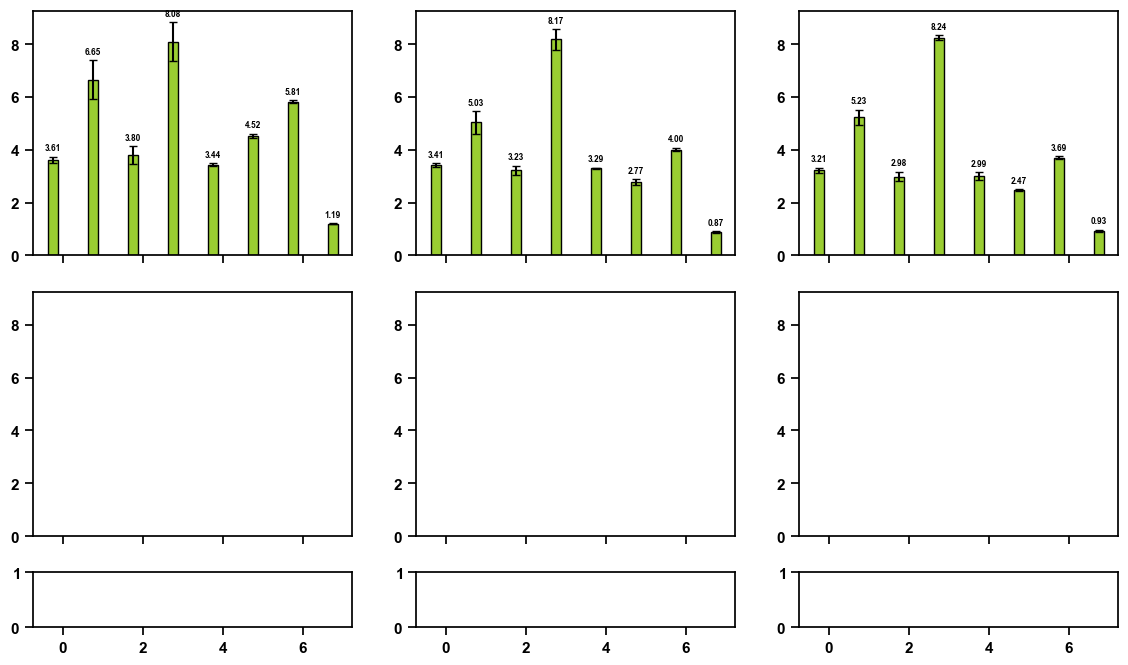

In [13]:
fig, ax = plt.subplots(3, 3, figsize=(14,8), sharex=True, sharey=False, height_ratios=[0.45, 0.45, 0.1])

# Example: share y only within the first two rows (left <-> right),
# but leave the third row independent.
ax[0,0].sharey(ax[0,1])
ax[0,1].sharey(ax[0,2])
ax[1,0].sharey(ax[0,0])
ax[1,1].sharey(ax[1,0])
ax[1,2].sharey(ax[1,1])
ax[2,1].sharey(ax[2,0])
ax[2,0].sharey(ax[2,2])

hue_order = [1, 20, 45]
bar_width = 0.25
cmap = ['yellowgreen', 'turquoise', 'indianred']

# Default Model xLSTM
x_labels = dfcomp_30_default['Test'].unique()
x_pos = np.arange(len(x_labels))
for i, hue_val in enumerate(hue_order):
    subset = dfcomp_0_default[dfcomp_0_default['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars1 = ax[0,0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars1):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_30_default[dfcomp_30_default['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars2 = ax[0,1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars2):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        

    subset = dfcomp_60_default[dfcomp_60_default['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars3 = ax[0,2].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars3):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,2].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    # Smaller Models xLSTM

    subset = dfcomp_0_smaller[dfcomp_0_smaller['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars4 = ax[1,0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars4):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_30_smaller[dfcomp_30_smaller['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars5 = ax[1,1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars5):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        

# for i, hue_val in enumerate(hue_order):
    subset = dfcomp_60_smaller[dfcomp_60_smaller['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars6 = ax[1,2].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars6):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,2].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')

    ax[2,0].bar(
        xpos,
        bars1.datavalues - bars4.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    ax[2,1].bar(
        xpos,
        bars2.datavalues - bars5.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )
    ax[2,2].bar(
        xpos,
        bars3.datavalues - bars6.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )   

for i, ax1 in enumerate(ax):
    if i == 0:
        emb = 96
    elif i == 1:
        emb = 32
    for j, axis in enumerate(ax1):
        s = 30 if j == 1 else 60
        s = 0 if j == 0 else s
        if i < 2:
            axis.legend(title=f"Smoothing: {s}\nEmb Dim: {emb}\nDivide by -", title_fontproperties={'size':8,'weight':'bold'}, fontsize=8)

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        axis.set_xticks(x_pos)
        axis.set_xticklabels(x_labels)
        axis.set_xlabel('Julian Day') if i == 2 else axis.set_xlabel("")
        if j == 0 and i != 2:
            axis.set_ylabel('Mean Squared Error')
        elif j == 0 and i == 2:
            axis.set_ylabel('MSE\nDiff')
        else:
            axis.set_ylabel("")
        axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)

fig.tight_layout()
fig.savefig(f"./output_images3/Method_Comparsion_context{context_len}_subwindow{sub_window_size}.png", dpi=600)

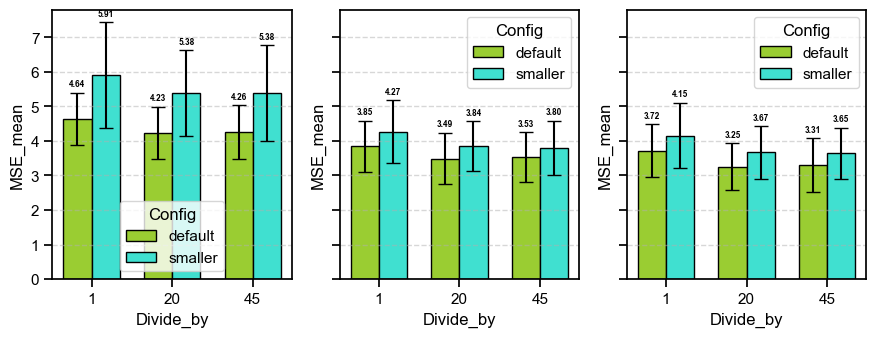

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(10.5,3.5), sharey=True)
temp = pd.concat([dfcomp_0_default, dfcomp_0_smaller], axis=0)
temp = temp[temp['Test'] != 183]
plot_grouped_bar_with_error(temp, 'Divide_by', 'MSE_mean', 'Config', ['default', 'smaller'], ax=ax[0])
temp = pd.concat([dfcomp_30_default, dfcomp_30_smaller], axis=0)
temp = temp[temp['Test'] != 183]
plot_grouped_bar_with_error(temp, 'Divide_by', 'MSE_mean', 'Config', ['default', 'smaller'], ax=ax[1])
temp = pd.concat([dfcomp_60_default, dfcomp_60_smaller], axis=0)
temp = temp[temp['Test'] != 183]
plot_grouped_bar_with_error(temp, 'Divide_by', 'MSE_mean', 'Config', ['default', 'smaller'], ax=ax[2])

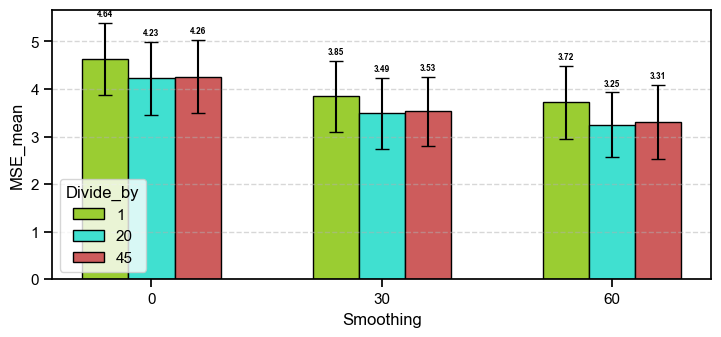

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8.5,3.5))
temp = pd.concat([dfcomp_0_default, dfcomp_30_default, dfcomp_60_default], axis=0)
# temp = temp[temp['Test'] != '183']
plot_grouped_bar_with_error(temp, 'Smoothing', 'MSE_mean', 'Divide_by', [1, 20, 45], ax=ax, bar_width=0.2)
# temp = pd.concat([dfcomp_60_default, dfcomp_60_smaller], axis=0)
# temp = temp[temp['Test'] != 183]
# plot_grouped_bar_with_error(temp, 'Config', 'MSE_mean', 'Divide_by', [1, 20, 45], ax=ax[1], bar_width=0.2)

In [115]:
# fig, ax = plt.subplots(3, 2, figsize=(8.5, 8.5), sharex=True, sharey=True)

# hue_order = ['LSTM', 'xLSTM']
# bar_width = 0.35
# cmap = ['yellowgreen', 'turquoise', 'indianred']

# for j, df_compile in enumerate([dfcomp_0, dfcomp_30, dfcomp_60]):
#     temp = df_compile[df_compile['Config'] == 'default']
#     x_labels = temp['Test'].unique()
#     x_pos = np.arange(len(x_labels))

#     for i, hue_val in enumerate(hue_order):
#         subset = temp[temp['Model'] == hue_val]
#         offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
#         xpos = x_pos + offset

#         bars = ax[j,0].bar(
#             xpos,
#             subset['MSE_mean'],
#             yerr=subset['MSE_se'],
#             width=bar_width,
#             label=hue_val,
#             color=cmap[i],
#             capsize=5,
#             edgecolor='black'
#         )

#         # Annotate bars with height
#         for bar in bars:
#             height = bar.get_height()
#             ax[j,0].annotate(f'{height:.2f}',
#                         xy=(bar.get_x() + bar.get_width() / 2, height),
#                         xytext=(0, 3),
#                         textcoords='offset points',
#                         ha='center', va='bottom',
#                         fontsize=6,
#                         fontweight='bold')
            
#     ax[j,0].set_xticks(x_pos)
#     ax[j,0].set_xticklabels(x_labels)
#     if j == 2:
#         ax[j,0].set_xlabel('Julian Day')
#     ax[j,0].set_ylabel('MSE')
#     ax[j,0].legend(title=f'Model, {temp["Smoothing"][0]}', fontsize=6)

    

# # temp = df_compile[df_compile['Config'] == 'smaller']
# # x_labels = temp['Test'].unique()
# # x_pos = np.arange(len(x_labels))

# # for i, hue_val in enumerate(hue_order):
# #     subset = temp[temp['Model'] == hue_val]
# #     offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
# #     xpos = x_pos + offset

# #     bars = ax[1].bar(
# #         xpos,
# #         subset['MSE_mean'],
# #         yerr=subset['MSE_se'],
# #         width=bar_width,
# #         label=hue_val,
# #         color=cmap[i],
# #         capsize=5,
# #         edgecolor='black'
# #     )

# # ax[1].set_xticks(x_pos)
# # ax[1].set_xticklabels(x_labels)
# # ax[1].set_xlabel('Julian Day')
# # ax[1].set_ylabel('MSE')
# # ax[1].legend(title='Model')

# fig.suptitle(f"Divide by : {divide_by}")
# fig.tight_layout()

# Context Length Tuning

In [7]:
# context_len = 5
sub_window_size = 5
# file_name = "model_evaluation/evaluation_output_wo_noise.txt"
file_name = "model_evaluation/evaluation_output_constrained.txt"
column_names = ['Model','Config','Time_To_Train','Test','Val','Interval','MSE','RMSE','MAE','R2','Corr','PearsonR','Hist-WMSE']
#########################################################
for context_len in [3, 5]:
    for smoothing in [0, 30, 60]:
        for divide_by in [1, 20, 45]:
            base_dir = f"../comparison_baseline_tt_{context_len}_15_1"
            df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                            names=column_names,
                            ).drop(0, axis=0).reset_index(inplace=False, drop=True)
            df1['Interval'] = df1['Interval'].astype(int)
            df1['MSE'] = df1['MSE'].astype(float)
            df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
            df1['Repeat'] = [1] * len(df1)
            df = df1
            base_dir = f"../comparison_baseline_tt_{context_len}_15_2"
            df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                            names=column_names,
                            ).drop(0, axis=0).reset_index(inplace=False, drop=True)
            df1['Interval'] = df1['Interval'].astype(int)
            df1['MSE'] = df1['MSE'].astype(float)
            df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
            df1['Repeat'] = [2] * len(df1)
            df = pd.concat([df, df1], axis=0)
            base_dir = f"../comparison_baseline_tt_{context_len}_15_3"
            df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                            names=column_names,
                            ).drop(0, axis=0).reset_index(inplace=False, drop=True)
            df1['Interval'] = df1['Interval'].astype(int)
            df1['MSE'] = df1['MSE'].astype(float)
            df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
            df1['Repeat'] = [3] * len(df1)
            df = pd.concat([df, df1], axis=0)
            df = df[df['Test'] != '183']
            globals()[f"df{context_len}_{smoothing}_{divide_by}"] = df.reset_index(drop=True).copy()
            del df
#########################################################
# dfcomp_0 = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
# dfcomp_30 = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
# dfcomp_60 = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
# for smoothing, in_df, out_df in zip([0, 30, 60], [df_0_1, df_30_1, df_60_1], [dfcomp_0, dfcomp_30, dfcomp_60]):
#     for model in ['LSTM', 'xLSTM']:
#         for config in ['default', 'smaller']:
#             temp = in_df[(in_df['Model'] == model) & (in_df['Config'] == config)].groupby('Test').agg(
#                 mean_y=('MSE', 'mean'),
#                 se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
#             )
#             for idx, row in temp.iterrows():
#                 out_df.loc[len(out_df)] = [model, config, row.name, 15, smoothing, divide_by, row['mean_y'], row['se_y']]

In [8]:
context_len = 3
df3_0_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df3_0_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df3_0_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 0
for divide_by, out_df in zip([1, 20, 45], [df3_0_1_comp, df3_0_20_comp, df3_0_45_comp]):
    temp = globals()[f"df{context_len}_{smoothing}_{divide_by}"][(globals()[f"df{context_len}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df3_30_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df3_30_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df3_30_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 30
for divide_by, out_df in zip([1, 20, 45], [df3_30_1_comp, df3_30_20_comp, df3_30_45_comp]):
    temp = globals()[f"df{context_len}_{smoothing}_{divide_by}"][(globals()[f"df{context_len}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df3_60_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df3_60_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df3_60_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 60
for divide_by, out_df in zip([1, 20, 45], [df3_60_1_comp, df3_60_20_comp, df3_60_45_comp]):
    temp = globals()[f"df{context_len}_{smoothing}_{divide_by}"][(globals()[f"df{context_len}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]
        
dfcomp_0_default3 = pd.concat([df3_0_1_comp, df3_0_20_comp, df3_0_45_comp], axis=0)
dfcomp_30_default3 = pd.concat([df3_30_1_comp, df3_30_20_comp, df3_30_45_comp], axis=0)
dfcomp_60_default3 = pd.concat([df3_60_1_comp, df3_60_20_comp, df3_60_45_comp], axis=0)

In [9]:
context_len = 5
df5_0_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_0_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_0_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 0
for divide_by, out_df in zip([1, 20, 45], [df5_0_1_comp, df5_0_20_comp, df5_0_45_comp]):
    temp = globals()[f"df{context_len}_{smoothing}_{divide_by}"][(globals()[f"df{context_len}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df5_30_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_30_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_30_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 30
for divide_by, out_df in zip([1, 20, 45], [df5_30_1_comp, df5_30_20_comp, df5_30_45_comp]):
    temp = globals()[f"df{context_len}_{smoothing}_{divide_by}"][(globals()[f"df{context_len}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df5_60_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_60_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_60_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 60
for divide_by, out_df in zip([1, 20, 45], [df5_60_1_comp, df5_60_20_comp, df5_60_45_comp]):
    temp = globals()[f"df{context_len}_{smoothing}_{divide_by}"][(globals()[f"df{context_len}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]
        
dfcomp_0_default5 = pd.concat([df5_0_1_comp, df5_0_20_comp, df5_0_45_comp], axis=0)
dfcomp_30_default5 = pd.concat([df5_30_1_comp, df5_30_20_comp, df5_30_45_comp], axis=0)
dfcomp_60_default5 = pd.concat([df5_60_1_comp, df5_60_20_comp, df5_60_45_comp], axis=0)

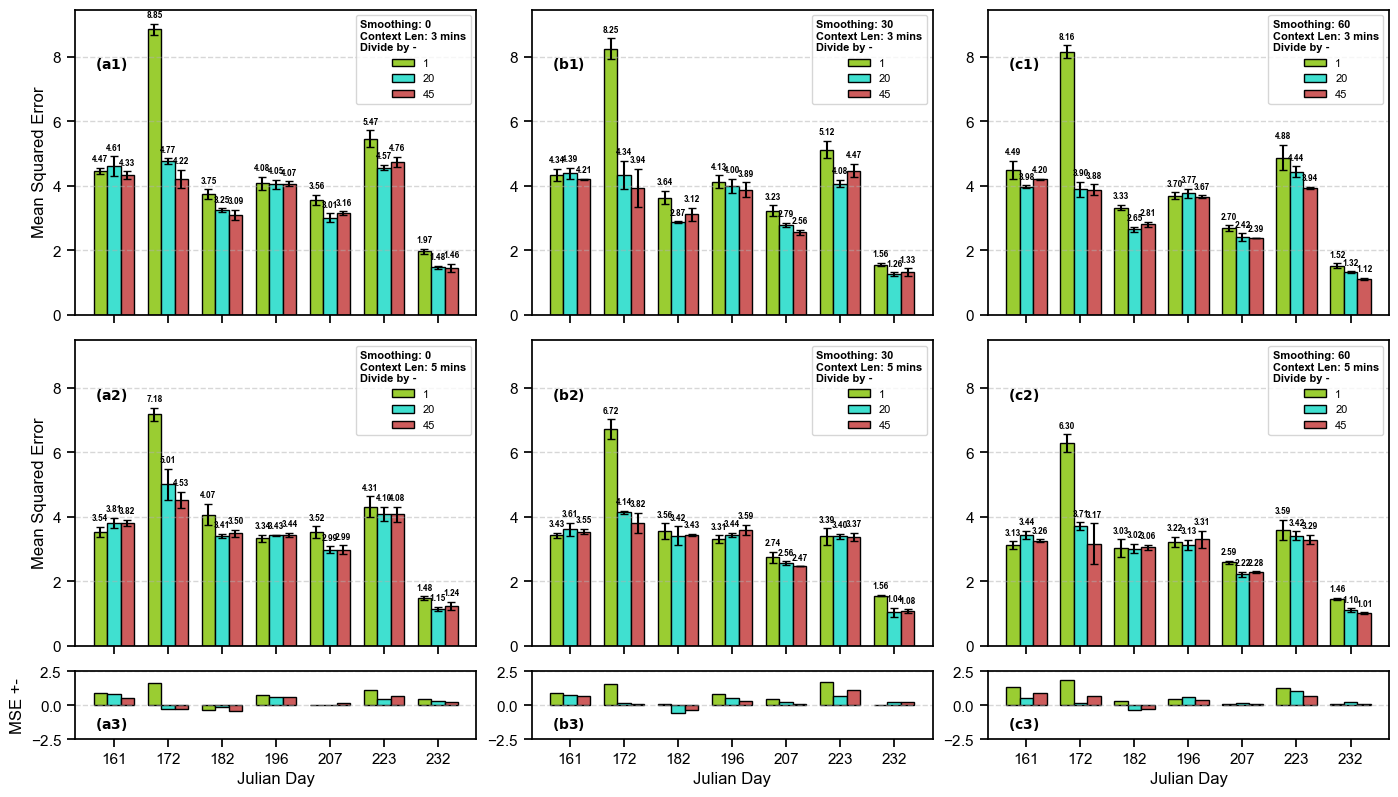

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(14,8), sharex=True, sharey=False, height_ratios=[0.45, 0.45, 0.1])

# Example: share y only within the first two rows (left <-> right),
# but leave the third row independent.
ax[0,0].sharey(ax[0,1])
ax[0,1].sharey(ax[0,2])
ax[1,0].sharey(ax[0,0])
ax[1,1].sharey(ax[1,0])
ax[1,2].sharey(ax[1,1])
ax[2,1].sharey(ax[2,0])
ax[2,0].sharey(ax[2,2])

hue_order = [1, 20, 45]
bar_width = 0.25
cmap = ['yellowgreen', 'turquoise', 'indianred']

# Default Model xLSTM
x_labels = dfcomp_30_default3['Test'].unique()
x_pos = np.arange(len(x_labels))
for i, hue_val in enumerate(hue_order):
    subset = dfcomp_0_default3[dfcomp_0_default3['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars1 = ax[0,0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars1):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_30_default3[dfcomp_30_default3['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars2 = ax[0,1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars2):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        

    subset = dfcomp_60_default3[dfcomp_60_default3['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars3 = ax[0,2].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars3):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,2].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    # Smaller Models xLSTM

    subset = dfcomp_0_default5[dfcomp_0_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars4 = ax[1,0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars4):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_30_default5[dfcomp_30_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars5 = ax[1,1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars5):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        

# for i, hue_val in enumerate(hue_order):
    subset = dfcomp_60_default5[dfcomp_60_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars6 = ax[1,2].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars6):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,2].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')

    ax[2,0].bar(
        xpos,
        bars1.datavalues - bars4.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    ax[2,1].bar(
        xpos,
        bars2.datavalues - bars5.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )
    ax[2,2].bar(
        xpos,
        bars3.datavalues - bars6.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )   

for i, ax1 in enumerate(ax):
    if i == 0:
        context_len = 3
    elif i == 1:
        context_len = 5
    for j, axis in enumerate(ax1):
        s = 30 if j == 1 else 60
        s = 0 if j == 0 else s
        if i < 2:
            axis.legend(title=f"Smoothing: {s}\nContext Len: {context_len} mins\nDivide by -", title_fontproperties={'size':7, 'weight':'bold'}, fontsize=7)

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        axis.set_xticks(x_pos)
        axis.set_xticklabels(x_labels)
        axis.set_xlabel('Julian Day') if i == 2 else axis.set_xlabel("")
        if j == 0 and i != 2:
            axis.set_ylabel('Mean Squared Error')
        elif j == 0 and i == 2:
            axis.set_ylabel('MSE +-')
        else:
            axis.set_ylabel("")
        axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)

ax[2,1].set_ylim(-2.5, 2.5);
img_lab = [
    [r"$\mathbf{(a1)}$", r"$\mathbf{(b1)}$", r"$\mathbf{(c1)}$"],
    [r"$\mathbf{(a2)}$", r"$\mathbf{(b2)}$", r"$\mathbf{(c2)}$"],
    [r"$\mathbf{(a3)}$", r"$\mathbf{(b3)}$", r"$\mathbf{(c3)}$"]
]
for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        if i == 2:
            axis.text(0.025, 0.15, img_lab[i][j], transform=axis.transAxes, fontsize=10, fontweight="bold", va='top', ha='left')
        else:
            axis.text(0.025, 0.85, img_lab[i][j], transform=axis.transAxes, fontsize=10, fontweight="bold", va='top', ha='left')
fig.tight_layout()
fig.savefig(f"./output_images4/cont_len_tun/method_comparsion_subwindow{sub_window_size}.png", dpi=600)

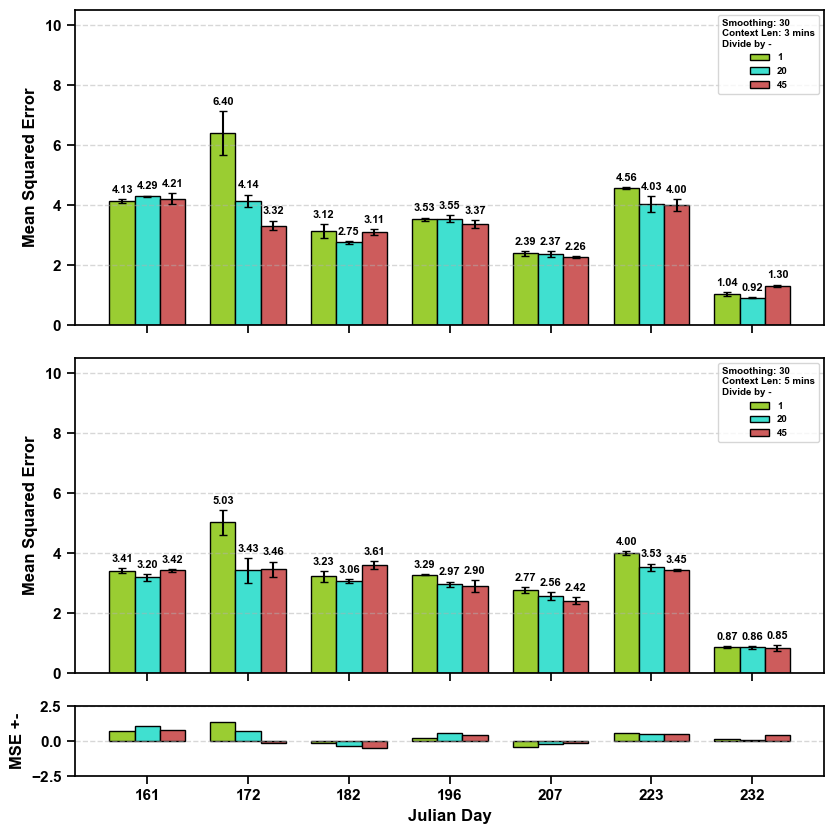

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(8.5,8.5), sharex=True, sharey=False, height_ratios=[0.45, 0.45, 0.1])

# Example: share y only within the first two rows (left <-> right),
# but leave the third row independent.
ax[0].sharey(ax[1])

hue_order = [1, 20, 45]
bar_width = 0.25
cmap = ['yellowgreen', 'turquoise', 'indianred']

# Default Model xLSTM
x_labels = dfcomp_0_default3['Test'].unique()
x_pos = np.arange(len(x_labels))
for i, hue_val in enumerate(hue_order):
    subset = dfcomp_30_default3[dfcomp_30_default3['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset
    
    bars3 = ax[0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars3):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
    
    subset = dfcomp_30_default5[dfcomp_30_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars6 = ax[1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars6):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
        
    ax[2].bar(
        xpos,
        bars3.datavalues - bars6.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )   

s = 30
for i, axis, in enumerate(ax):
    if i == 0:
        context_len = 3
    elif i == 1:
        context_len = 5
    if i < 2:
        axis.legend(title=f"Smoothing: {s}\nContext Len: {context_len} mins\nDivide by -", title_fontproperties={'size':7, 'weight':'bold'}, fontsize=7)

for i, axis in enumerate(ax):
    axis.set_xticks(x_pos)
    axis.set_xticklabels(x_labels)
    axis.set_xlabel('Julian Day') if i == 2 else axis.set_xlabel("")
    if i == 2:
        axis.set_ylabel('MSE +-')
    else:
        axis.set_ylabel('Mean Squared Error')
    axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)

ax[0].set_ylim(0, 10.5)
ax[2].set_ylim(-2.5, 2.5);
# img_lab = [r"$\mathbf{(a)}$", r"$\mathbf{(b)}$", r"$\mathbf{(c)}$"]

# for i, axis in enumerate(ax):
    # if i == 2:
        # axis.text(0.01, 0.25, img_lab[i], transform=axis.transAxes, fontsize=8, fontweight="bold", va='top', ha='left')
    # else:
        # axis.text(0.01, 0.90, img_lab[i], transform=axis.transAxes, fontsize=8, fontweight="bold", va='top', ha='left')
fig.tight_layout()
fig.savefig(f"./output_images4/cont_len_tun/method_comparsion_subwindow{sub_window_size}_smoothing{s}.png", dpi=600)

In [20]:
compile_df = pd.DataFrame(columns=['Test', 'Smoothing', 'Divide_by', 't-stat', 'p-val'])

for smoothing in [0, 30, 60]:
    for div_by in [1, 20, 45]:
        for julday in globals()[f"df3_{smoothing}_{div_by}"]['Test'].unique():
            diff = globals()[f"df3_{smoothing}_{div_by}"][globals()[f"df3_{smoothing}_{div_by}"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df5_{smoothing}_{div_by}"][globals()[f"df5_{smoothing}_{div_by}"]['Test'] == julday]['MSE'].to_numpy()
            mean_diff = diff.mean()
            se_diff = diff.std()/np.sqrt(len(diff))
            t_stat = mean_diff / se_diff
            p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
            # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
            compile_df.loc[len(compile_df)] = [julday, smoothing, div_by, t_stat, p_val]
compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.15 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["5" if i > 0 else "3" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
print(f"Ratio 5 > 3 in Rejected : {Counter(["5" if i > 0 else "3" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])['5']/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")

Counter({'Reject': 44, 'Accept': 19})
Counter({'5': 37, '3': 7})
Ratio Rejected : 0.70
Ratio 5 > 3 in Rejected : 0.84


In [21]:
compile_df = pd.DataFrame(columns=['Test', 'Smoothing', 'Divide_by', 't-stat', 'p-val'])

for smoothing in [0, 30, 60]:
    for div_by in [1, 20, 45]:
        for julday in globals()[f"df3_{smoothing}_{div_by}"]['Test'].unique():
            diff = globals()[f"df3_{smoothing}_{div_by}"][globals()[f"df3_{smoothing}_{div_by}"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df5_{smoothing}_{div_by}"][globals()[f"df5_{smoothing}_{div_by}"]['Test'] == julday]['MSE'].to_numpy()
            mean_diff = diff.mean()
            se_diff = diff.std()/np.sqrt(len(diff))
            t_stat = mean_diff / se_diff
            p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
            # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
            compile_df.loc[len(compile_df)] = [julday, smoothing, div_by, t_stat, p_val]
compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.15 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["5" if i > 0 else "3" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
print(f"Ratio 5 > 3 in Rejected : {Counter(["5" if i > 0 else "3" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])['5']/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")

Counter({'Reject': 44, 'Accept': 19})
Counter({'5': 37, '3': 7})
Ratio Rejected : 0.70
Ratio 5 > 3 in Rejected : 0.84


In [22]:
compile_df = pd.DataFrame(columns=['Test', 'Smoothing', 'Divide_by', 't-stat', 'p-val'])

for smoothing in [0, 30, 60]:
    for div_by in [1, 20, 45]:
        for julday in globals()[f"df3_{smoothing}_{div_by}"]['Test'].unique():
            diff = globals()[f"df3_{smoothing}_{div_by}"][globals()[f"df3_{smoothing}_{div_by}"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df5_{smoothing}_{div_by}"][globals()[f"df5_{smoothing}_{div_by}"]['Test'] == julday]['MSE'].to_numpy()
            mean_diff = diff.mean()
            se_diff = diff.std()/np.sqrt(len(diff))
            t_stat = mean_diff / se_diff
            p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
            # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
            compile_df.loc[len(compile_df)] = [julday, smoothing, div_by, t_stat, p_val]
compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.15 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["5" if i > 0 else "3" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
print(f"Ratio 5 > 3 in Rejected : {Counter(["5" if i > 0 else "3" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])['5']/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")

Counter({'Reject': 44, 'Accept': 19})
Counter({'5': 37, '3': 7})
Ratio Rejected : 0.70
Ratio 5 > 3 in Rejected : 0.84


# Tuning Sub-window Size

In [23]:
context_len = 5
# sub_window_size = 30
file_name = "model_evaluation/evaluation_output_constrained.txt"
column_names = ['Model','Config','Time_To_Train','Test','Val','Interval','MSE','RMSE','MAE','R2','Corr','PearsonR','Hist-WMSE']
#########################################################
# for context_len in [3, 5]:
for sub_window_size in [5, 15, 30]:
    for smoothing in [0, 30, 60]:
        for divide_by in [1, 20, 45]:
            base_dir = f"../comparison_baseline_tt_{context_len}_15_1"
            df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                            names=column_names,
                            ).drop(0, axis=0).reset_index(inplace=False, drop=True)
            df1['Interval'] = df1['Interval'].astype(int)
            df1['MSE'] = df1['MSE'].astype(float)
            df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
            df1['Repeat'] = [1] * len(df1)
            df = df1
            base_dir = f"../comparison_baseline_tt_{context_len}_15_2"
            df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                            names=column_names,
                            ).drop(0, axis=0).reset_index(inplace=False, drop=True)
            df1['Interval'] = df1['Interval'].astype(int)
            df1['MSE'] = df1['MSE'].astype(float)
            df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
            df1['Repeat'] = [2] * len(df1)
            df = pd.concat([df, df1], axis=0)
            base_dir = f"../comparison_baseline_tt_{context_len}_15_3"
            df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                            names=column_names,
                            ).drop(0, axis=0).reset_index(inplace=False, drop=True)
            df1['Interval'] = df1['Interval'].astype(int)
            df1['MSE'] = df1['MSE'].astype(float)
            df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
            df1['Repeat'] = [3] * len(df1)
            df = pd.concat([df, df1], axis=0)
            # df = df[df['Test'] != '183']
            globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"] = df.reset_index(drop=True).copy()
            del df
#########################################################

In [24]:
context_len = 5
sub_window_size = 5
df5_0_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_0_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_0_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 0
for divide_by, out_df in zip([1, 20, 45], [df5_0_1_comp, df5_0_20_comp, df5_0_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df5_30_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_30_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_30_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 30
for divide_by, out_df in zip([1, 20, 45], [df5_30_1_comp, df5_30_20_comp, df5_30_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df5_60_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_60_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df5_60_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 60
for divide_by, out_df in zip([1, 20, 45], [df5_60_1_comp, df5_60_20_comp, df5_60_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]
        
dfcomp_0_default5 = pd.concat([df5_0_1_comp, df5_0_20_comp, df5_0_45_comp], axis=0)
dfcomp_30_default5 = pd.concat([df5_30_1_comp, df5_30_20_comp, df5_30_45_comp], axis=0)
dfcomp_60_default5 = pd.concat([df5_60_1_comp, df5_60_20_comp, df5_60_45_comp], axis=0)

In [25]:
context_len = 5
sub_window_size = 15
df15_0_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df15_0_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df15_0_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 0
for divide_by, out_df in zip([1, 20, 45], [df15_0_1_comp, df15_0_20_comp, df15_0_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df15_30_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df15_30_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df15_30_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 30
for divide_by, out_df in zip([1, 20, 45], [df15_30_1_comp, df15_30_20_comp, df15_30_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df15_60_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df15_60_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df15_60_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 60
for divide_by, out_df in zip([1, 20, 45], [df15_60_1_comp, df15_60_20_comp, df15_60_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]
        
dfcomp_0_default15 = pd.concat([df15_0_1_comp, df15_0_20_comp, df15_0_45_comp], axis=0)
dfcomp_30_default15 = pd.concat([df15_30_1_comp, df15_30_20_comp, df15_30_45_comp], axis=0)
dfcomp_60_default15 = pd.concat([df15_60_1_comp, df15_60_20_comp, df15_60_45_comp], axis=0)

In [26]:
context_len = 5
sub_window_size = 30
df30_0_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df30_0_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df30_0_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 0
for divide_by, out_df in zip([1, 20, 45], [df30_0_1_comp, df30_0_20_comp, df30_0_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df30_30_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df30_30_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df30_30_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 30
for divide_by, out_df in zip([1, 20, 45], [df30_30_1_comp, df30_30_20_comp, df30_30_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df30_60_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df30_60_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df30_60_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 60
for divide_by, out_df in zip([1, 20, 45], [df30_60_1_comp, df30_60_20_comp, df30_60_45_comp]):
    temp = globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"][(globals()[f"df{sub_window_size}_{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]
        
dfcomp_0_default30 = pd.concat([df30_0_1_comp, df30_0_20_comp, df30_0_45_comp], axis=0)
dfcomp_30_default30 = pd.concat([df30_30_1_comp, df30_30_20_comp, df30_30_45_comp], axis=0)
dfcomp_60_default30 = pd.concat([df30_60_1_comp, df30_60_20_comp, df30_60_45_comp], axis=0)

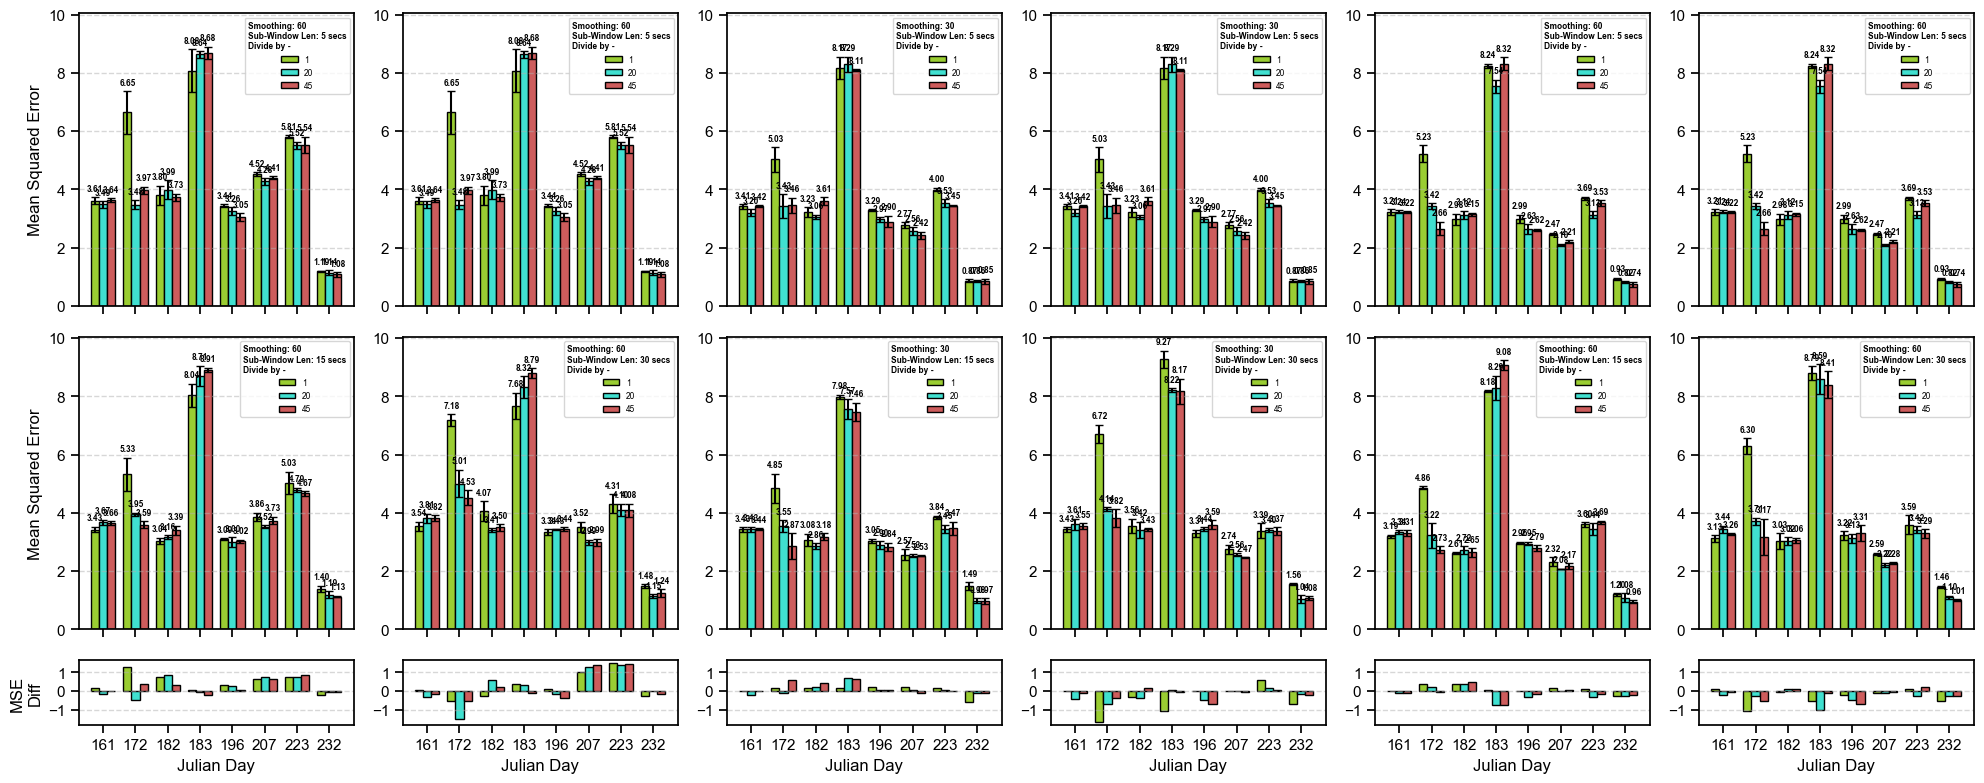

In [ ]:
fig, ax = plt.subplots(3, 6, figsize=(20,8), sharex=True, sharey=False, height_ratios=[0.45, 0.45, 0.1])

# Example: share y only within the first two rows (left <-> right),
# but leave the third row independent.
for i in range(6-1):
    ax[0,i+1].sharey(ax[0,i])
    ax[1,i+1].sharey(ax[1,i])
    ax[2,i+1].sharey(ax[2,i])

ax[1,0].sharey(ax[0,0])

hue_order = [1, 20, 45]
bar_width = 0.25
cmap = ['yellowgreen', 'turquoise', 'indianred']

# Default Model xLSTM
x_labels = dfcomp_30_default5['Test'].unique()
x_pos = np.arange(len(x_labels))
for i, hue_val in enumerate(hue_order):
    subset = dfcomp_0_default5[dfcomp_0_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars1 = ax[0,0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars1):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_0_default5[dfcomp_0_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars2 = ax[0,1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars2):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        

    subset = dfcomp_30_default5[dfcomp_30_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars3 = ax[0,2].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars3):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,2].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_30_default5[dfcomp_30_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars4 = ax[0,3].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars4):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,3].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_60_default5[dfcomp_60_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars5 = ax[0,4].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars5):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,4].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_60_default5[dfcomp_60_default5['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars6 = ax[0,5].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars6):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,5].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_0_default15[dfcomp_0_default15['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars7 = ax[1,0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars7):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_0_default30[dfcomp_0_default30['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars8 = ax[1,1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars8):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_30_default15[dfcomp_30_default15['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars9 = ax[1,2].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars9):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,2].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_30_default30[dfcomp_30_default30['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars10 = ax[1,3].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars10):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,3].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_60_default15[dfcomp_60_default15['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars11 = ax[1,4].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars11):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,4].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
    subset = dfcomp_60_default30[dfcomp_60_default30['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars12 = ax[1,5].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars12):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,5].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
    
    ax[2,0].bar(
        xpos,
        bars1.datavalues - bars7.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    ax[2,1].bar(
        xpos,
        bars2.datavalues - bars8.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )
    ax[2,2].bar(
        xpos,
        bars3.datavalues - bars9.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )
    ax[2,3].bar(
        xpos,
        bars4.datavalues - bars10.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )
    ax[2,4].bar(
        xpos,
        bars5.datavalues - bars11.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )
    ax[2,5].bar(
        xpos,
        bars6.datavalues - bars12.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        if i == 0:
            sub_window_size = 5
        elif i == 1 and j%2 == 0:
            sub_window_size = 15
        elif i == 1 and j%2 == 1:
            sub_window_size = 30 

        s = 30 if j in [2,3] else 60
        s = 0 if j == [0,1] else s
        if i < 2:
            axis.legend(title=f"Smoothing: {s}\nSub-Window Len: {sub_window_size} secs\nDivide by -", title_fontproperties={'size':6,'weight':'bold'}, fontsize=6)

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        axis.set_xticks(x_pos)
        axis.set_xticklabels(x_labels)
        axis.set_xlabel('Julian Day') if i == 2 else axis.set_xlabel("")
        if j == 0 and i != 2:
            axis.set_ylabel('Mean Squared Error')
        elif j == 0 and i == 2:
            axis.set_ylabel('MSE\nDiff')
        else:
            axis.set_ylabel("")
        axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)

fig.tight_layout()
# fig.savefig(f"./output_images3/Method_Comparsion_subwindow{sub_window_size}.png", dpi=600)

# Tuning Smoothing and Divide By

In [11]:
context_len = 5
sub_window_size = 5
# file_name = "model_evaluation/evaluation_output_wo_noise.txt"
file_name = "model_evaluation/evaluation_output_constrained.txt"
column_names = ['Model','Config','Time_To_Train','Test','Val','Interval','MSE','RMSE','MAE','R2','Corr','PearsonR','Hist-WMSE']
#########################################################
for smoothing in [0, 30, 60]:
    for divide_by in [1, 20, 45]:
        base_dir = f"../comparison_baseline_tt_{context_len}_15_1"
        df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                        names=column_names,
                        ).drop(0, axis=0).reset_index(inplace=False, drop=True)
        df1['Interval'] = df1['Interval'].astype(int)
        df1['MSE'] = df1['MSE'].astype(float)
        df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
        df1['Repeat'] = [1] * len(df1)
        df = df1
        base_dir = f"../comparison_baseline_tt_{context_len}_15_2"
        df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                        names=column_names,
                        ).drop(0, axis=0).reset_index(inplace=False, drop=True)
        df1['Interval'] = df1['Interval'].astype(int)
        df1['MSE'] = df1['MSE'].astype(float)
        df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
        df1['Repeat'] = [2] * len(df1)
        df = pd.concat([df, df1], axis=0)
        base_dir = f"../comparison_baseline_tt_{context_len}_15_3"
        df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                        names=column_names,
                        ).drop(0, axis=0).reset_index(inplace=False, drop=True)
        df1['Interval'] = df1['Interval'].astype(int)
        df1['MSE'] = df1['MSE'].astype(float)
        df1 = df1[(df1['Interval'] == sub_window_size) & (df1['Model'] == 'xLSTM') & (df1['Config'] == 'default')]
        df1['Repeat'] = [3] * len(df1)
        df = pd.concat([df, df1], axis=0)
        df = df[df['Test'] != '183']
        globals()[f"df{smoothing}_{divide_by}"] = df.reset_index(drop=True).copy()
        del df
#########################################################

In [12]:
context_len = 5
# sub_window_size = 5
df0_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df0_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df0_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 0
for divide_by, out_df in zip([1, 20, 45], [df0_1_comp, df0_20_comp, df0_45_comp]):
    temp = globals()[f"df{smoothing}_{divide_by}"][(globals()[f"df{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df30_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df30_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df30_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 30
for divide_by, out_df in zip([1, 20, 45], [df30_1_comp, df30_20_comp, df30_45_comp]):
    temp = globals()[f"df{smoothing}_{divide_by}"][(globals()[f"df{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]

df60_1_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df60_20_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
df60_45_comp = pd.DataFrame(columns=['Model', 'Config', 'Test', 'Context', 'Interval', 'Smoothing', 'Divide_by', 'MSE_mean', 'MSE_se'])
smoothing = 60
for divide_by, out_df in zip([1, 20, 45], [df60_1_comp, df60_20_comp, df60_45_comp]):
    temp = globals()[f"df{smoothing}_{divide_by}"][(globals()[f"df{smoothing}_{divide_by}"]['Config'] == 'default')]
    # temp = temp[temp['MSE'] < 30]
    temp = temp.groupby('Test').agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
    for idx, row in temp.iterrows():
        out_df.loc[len(out_df)] = ['xLSTM', 'default', row.name, context_len, sub_window_size, smoothing, divide_by, row['mean_y'], row['se_y']]
        
dfcomp_0 = pd.concat([df0_1_comp, df0_20_comp, df0_45_comp], axis=0)
dfcomp_30 = pd.concat([df30_1_comp, df30_20_comp, df30_45_comp], axis=0)
dfcomp_60 = pd.concat([df60_1_comp, df60_20_comp, df60_45_comp], axis=0)

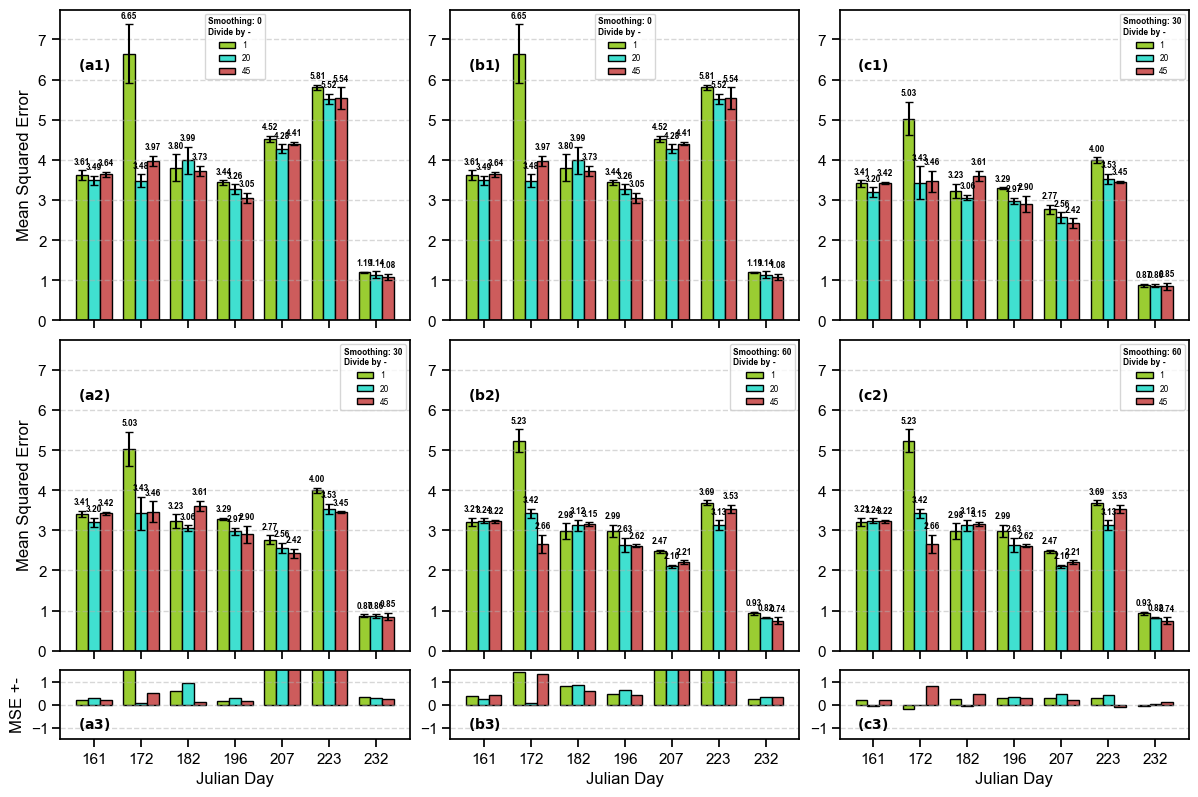

In [263]:
fig, ax = plt.subplots(3, 3, figsize=(12,8), sharex=True, sharey=False, height_ratios=[0.45, 0.45, 0.1])

# Example: share y only within the first two rows (left <-> right),
# but leave the third row independent.
for i in range(3-1):
    ax[0,i+1].sharey(ax[0,i])
    ax[1,i+1].sharey(ax[1,i])
    ax[2,i+1].sharey(ax[2,i])

ax[1,0].sharey(ax[0,0])

hue_order = [1, 20, 45]
bar_width = 0.25
cmap = ['yellowgreen', 'turquoise', 'indianred']

# Default Model xLSTM
x_labels = dfcomp_0['Test'].unique()
x_pos = np.arange(len(x_labels))

for i, hue_val in enumerate(hue_order):
    ####################
    subset = dfcomp_0[dfcomp_0['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars1 = ax[0,0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars1):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
    ####################
    subset = dfcomp_0[dfcomp_0['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars2 = ax[0,1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars2):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
    ####################
    subset = dfcomp_30[dfcomp_30['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars5 = ax[0,2].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars5):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,2].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
    ####################
    subset = dfcomp_30[dfcomp_30['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars3 = ax[1,0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars3):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
    ####################
    subset = dfcomp_60[dfcomp_60['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars4 = ax[1,1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars4):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
    ####################
    subset = dfcomp_60[dfcomp_60['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars6 = ax[1,2].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars6):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1,2].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
    ax[2,0].bar(
        xpos,
        bars1.datavalues - bars3.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )
    ax[2,1].bar(
        xpos,
        bars2.datavalues - bars4.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )
    ax[2,2].bar(
        xpos,
        bars5.datavalues - bars6.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        if i==0 and j!=2:
            s=0
        elif (i==0 and j==2) or (i==1 and j==0):
            s=30
        else:
            s=60        
        if i < 2:
            axis.legend(title=f"Smoothing: {s}\nDivide by -", title_fontproperties={'size':6,'weight':'bold'}, fontsize=6)

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        axis.set_xticks(x_pos)
        axis.set_xticklabels(x_labels)
        axis.set_xlabel('Julian Day') if i == 2 else axis.set_xlabel("")
        if j == 0 and i != 2:
            axis.set_ylabel('Mean Squared Error')
        elif j == 0 and i == 2:
            axis.set_ylabel('MSE +-')
        else:
            axis.set_ylabel("")
        axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)
ax[2,0].set_ylim(-1.5, 1.5)

img_lab = [
    [r"$\mathbf{(a1)}$", r"$\mathbf{(b1)}$", r"$\mathbf{(c1)}$"],
    [r"$\mathbf{(a2)}$", r"$\mathbf{(b2)}$", r"$\mathbf{(c2)}$"],
    [r"$\mathbf{(a3)}$", r"$\mathbf{(b3)}$", r"$\mathbf{(c3)}$"]
]
for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        if i == 2:
            axis.text(0.05, 0.35, img_lab[i][j], transform=axis.transAxes, fontsize=10, fontweight="bold", va='top', ha='left')
        else:
            axis.text(0.05, 0.85, img_lab[i][j], transform=axis.transAxes, fontsize=10, fontweight="bold", va='top', ha='left')

fig.tight_layout()
fig.savefig(f"./output_images3/smoothing_div_tuning/Model_Comparison_Smoothing_Divideby_sub{sub_window_size}.png", dpi=600)

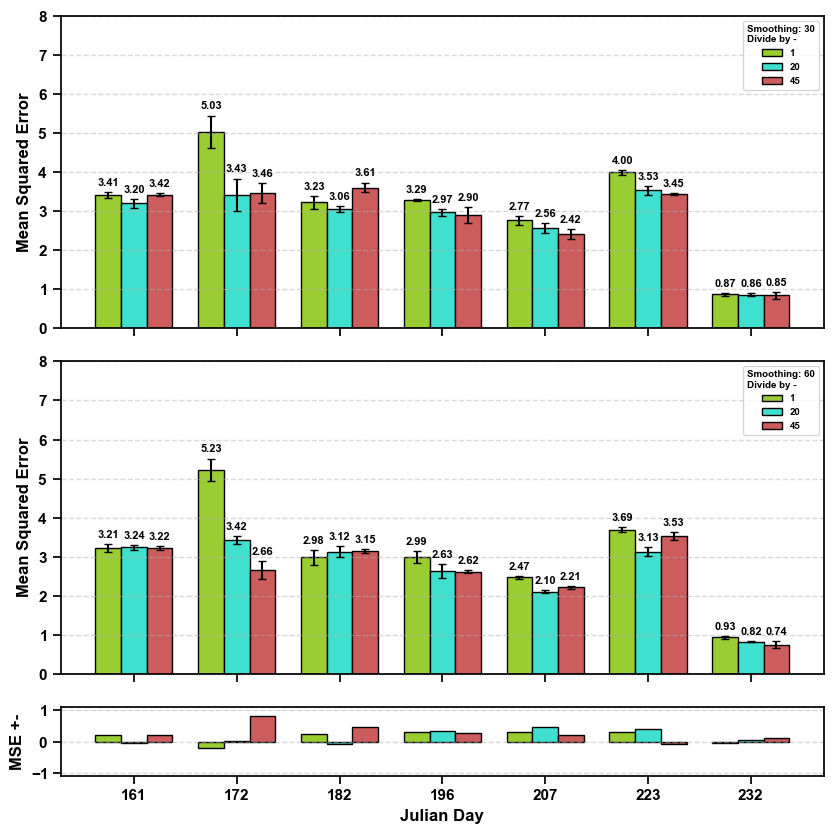

In [17]:
fig, ax = plt.subplots(3, 1, figsize=(8.5,8.5), sharex=True, sharey=False, height_ratios=[0.45, 0.45, 0.1])

ax[0].sharey(ax[1])

hue_order = [1, 20, 45]
bar_width = 0.25
cmap = ['yellowgreen', 'turquoise', 'indianred']

x_labels = dfcomp_0['Test'].unique()
x_pos = np.arange(len(x_labels))

for i, hue_val in enumerate(hue_order):
    ####################
    subset = dfcomp_30[dfcomp_30['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars5 = ax[0].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars5):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
        
    ####################
    subset = dfcomp_60[dfcomp_60['Divide_by'] == hue_val]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars6 = ax[1].bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars6):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
        
    ax[2].bar(
        xpos,
        bars5.datavalues - bars6.datavalues,
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

for i, axis, in enumerate(ax):
    if i == 0:
        s = 30
    elif i == 1:
        s = 60
    if i < 2:
        axis.legend(title=f"Smoothing: {s}\nDivide by -", title_fontproperties={'size':7, 'weight':'bold'}, fontsize=7)

for i, axis in enumerate(ax):
    axis.set_xticks(x_pos)
    axis.set_xticklabels(x_labels)
    axis.set_xlabel('Julian Day') if i == 2 else axis.set_xlabel("")
    if i == 2:
        axis.set_ylabel('MSE +-')
    else:
        axis.set_ylabel('Mean Squared Error')
    axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)

ax[0].set_ylim(0, 8)
ax[2].set_ylim(-1.1, 1.1);
# img_lab = [r"$\mathbf{(a)}$", r"$\mathbf{(b)}$", r"$\mathbf{(c)}$"]

# for i, axis in enumerate(ax):
#     if i == 2:
#         axis.text(0.01, 0.25, img_lab[i], transform=axis.transAxes, fontsize=8, fontweight="bold", va='top', ha='left')
#     else:
#         axis.text(0.01, 0.90, img_lab[i], transform=axis.transAxes, fontsize=8, fontweight="bold", va='top', ha='left')

fig.tight_layout()
fig.savefig(f"./output_images4/smoo_div_tun/subwindow{sub_window_size}_3.png", dpi=600)

### Compare 0, 30 and 0, 60

In [264]:
compile_df = pd.DataFrame(columns=['Test', 'Divide_by', 't-stat', 'p-val'])

for div_by in [1, 20, 45]:
    for julday in globals()[f"df0_{div_by}"]['Test'].unique():
        diff = globals()[f"df0_{div_by}"][globals()[f"df0_{div_by}"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df30_{div_by}"][globals()[f"df30_{div_by}"]['Test'] == julday]['MSE'].to_numpy()
        mean_diff = diff.mean()
        se_diff = diff.std()/np.sqrt(len(diff))
        t_stat = mean_diff / se_diff
        p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
        # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
        compile_df.loc[len(compile_df)] = [julday, div_by, t_stat, p_val]

compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.10 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["30" if i > 0 else "0" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
print(f"Ratio 30 > 0 in Rejected : {Counter(["30" if i > 0 else "0" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])['30']/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")

Counter({'Reject': 15, 'Accept': 6})
Counter({'30': 15})
Ratio Rejected : 0.71
Ratio 30 > 0 in Rejected : 1.00


In [265]:
compile_df = pd.DataFrame(columns=['Test', 'Divide_by', 't-stat', 'p-val'])

for div_by in [1, 20, 45]:
    for julday in globals()[f"df0_{div_by}"]['Test'].unique():
        diff = globals()[f"df0_{div_by}"][globals()[f"df0_{div_by}"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df60_{div_by}"][globals()[f"df60_{div_by}"]['Test'] == julday]['MSE'].to_numpy()
        mean_diff = diff.mean()
        se_diff = diff.std()/np.sqrt(len(diff))
        t_stat = mean_diff / se_diff
        p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
        # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
        compile_df.loc[len(compile_df)] = [julday, div_by, t_stat, p_val]

compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.10 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["60" if i > 0 else "0" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
print(f"Ratio 60 > 0 in Rejected : {Counter(["60" if i > 0 else "0" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])['60']/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")

Counter({'Reject': 16, 'Accept': 5})
Counter({'60': 16})
Ratio Rejected : 0.76
Ratio 60 > 0 in Rejected : 1.00


### Compare 30 and 60

In [266]:
compile_df = pd.DataFrame(columns=['Test', 'Divide_by', 't-stat', 'p-val'])

for div_by in [1, 20, 45]:
    for julday in globals()[f"df60_{div_by}"]['Test'].unique():
        diff = globals()[f"df60_{div_by}"][globals()[f"df60_{div_by}"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df30_{div_by}"][globals()[f"df30_{div_by}"]['Test'] == julday]['MSE'].to_numpy()
        mean_diff = diff.mean()
        se_diff = diff.std()/np.sqrt(len(diff))
        t_stat = mean_diff / se_diff
        p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
        # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
        compile_df.loc[len(compile_df)] = [julday, div_by, t_stat, p_val]

compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.10 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["30" if i > 0 else "60" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
print(f"Ratio 30 > 60 in Rejected : {Counter(["30" if i > 0 else "60" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])['30']/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")

Counter({'Accept': 14, 'Reject': 7})
Counter({'60': 7})
Ratio Rejected : 0.33
Ratio 30 > 60 in Rejected : 0.00


### Compare 1, 20 and 45

#### 1 vs 20

In [267]:
compile_df = pd.DataFrame(columns=['Test', 't-stat', 'p-val'])
smoothing=60
for julday in globals()[f"df60_1"]['Test'].unique():
    diff = globals()[f"df60_1"][globals()[f"df60_1"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df60_20"][globals()[f"df60_20"]['Test'] == julday]['MSE'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std()/np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
    # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.10 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["20" if i > 0 else "1" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
print(f"Ratio 20 > 1 in Rejected : {Counter(["20" if i > 0 else "1" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])['20']/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")

Counter({'Reject': 4, 'Accept': 3})
Counter({'20': 4})
Ratio Rejected : 0.57
Ratio 20 > 1 in Rejected : 1.00


#### 1 vs 45

In [268]:
compile_df = pd.DataFrame(columns=['Test', 't-stat', 'p-val'])
smoothing=60
for julday in globals()[f"df60_1"]['Test'].unique():
    diff = globals()[f"df60_1"][globals()[f"df60_1"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df60_45"][globals()[f"df60_45"]['Test'] == julday]['MSE'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std()/np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
    # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.10 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["45" if i > 0 else "1" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
print(f"Ratio 45 > 1 in Rejected : {Counter(["45" if i > 0 else "1" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])["45"]/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")

Counter({'Accept': 4, 'Reject': 3})
Counter({'45': 3})
Ratio Rejected : 0.43
Ratio 45 > 1 in Rejected : 1.00


#### 20 vs 45

In [269]:
compile_df = pd.DataFrame(columns=['Test', 't-stat', 'p-val'])
smoothing=60
for julday in globals()[f"df60_20"]['Test'].unique():
    diff = globals()[f"df60_20"][globals()[f"df60_20"]['Test'] == julday]['MSE'].to_numpy() - globals()[f"df60_45"][globals()[f"df60_45"]['Test'] == julday]['MSE'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std()/np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
    # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]
compile_df['Acc_or_Rej'] = compile_df['p-val'].apply(lambda x: "Reject" if x < 0.10 else "Accept")
print(Counter(compile_df['Acc_or_Rej']))
print(Counter(["45" if i > 0 else "20" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']]))
print(f"Ratio Rejected : {Counter(compile_df['Acc_or_Rej'])["Reject"]/len(compile_df):.2f}")
try:
    print(f"Ratio 45 > 20 in Rejected : {Counter(["45" if i > 0 else "20" for i in compile_df[compile_df['Acc_or_Rej'] == 'Reject']['t-stat']])["45"]/Counter(compile_df['Acc_or_Rej'])["Reject"]:.2f}")
except:
    print("None rejected")

Counter({'Accept': 5, 'Reject': 2})
Counter({'45': 1, '20': 1})
Ratio Rejected : 0.29
Ratio 45 > 20 in Rejected : 0.50


In [270]:
compile_df

,Test,t-stat,p-val,Acc_or_Rej
0,161,0.315971,0.781951,Accept
1,172,2.958002,0.097808,Reject
2,182,-0.195098,0.863339,Accept
3,196,0.091320,0.935561,Accept
4,207,-2.296192,0.148536,Accept
5,223,-2.955458,0.097953,Reject
6,232,1.224045,0.345560,Accept


In [271]:
d1 = df60_45.groupby(['Test']).agg(
    mse_mean=('MSE', 'mean'),
    mse_se=('MSE',lambda v: v.std(ddof=1) / np.sqrt(len(v)))
)
d2 = df60_20.groupby(['Test']).agg(
    mse_mean=('MSE', 'mean'),
    mse_se=('MSE',lambda v: v.std(ddof=1) / np.sqrt(len(v)))
)

In [272]:
d1

,mse_mean,mse_se
Test,,
161,3.220500,0.042966
172,2.656033,0.232984
182,3.150133,0.048720
196,2.619433,0.034217
207,2.211400,0.039674
223,3.531333,0.099439
232,0.742567,0.089667


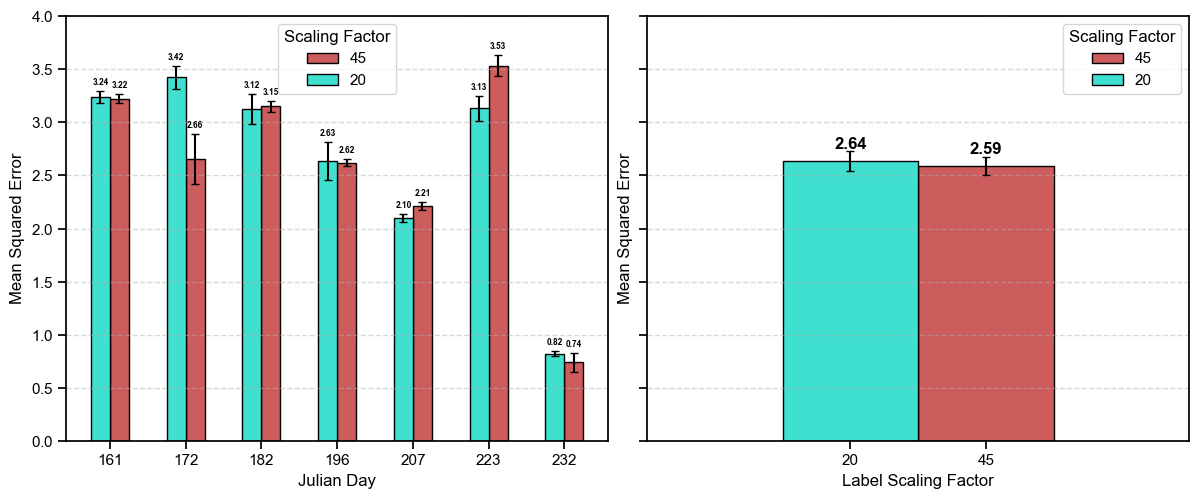

In [273]:
fig, ax = plt.subplots(1, 2, figsize=(12,5), sharey=True)

hue_order = [20, 45]
x_labels = d1.index.unique()
x_pos = np.arange(len(x_labels))

bar_width=0.25
offset = 0.25/2
xpos = x_pos + offset
bars1 = ax[0].bar(
        xpos,
        d1['mse_mean'],
        yerr=d1['mse_se'],
        width=bar_width,
        label='45',
        color='indianred',
        capsize=3,
        edgecolor='black'
    )

# Annotate bars on top of the error bar caps
for j, bar in enumerate(bars1):
    height = bar.get_height()
    err = float(d1['mse_se'].iloc[j])
    y = height + err  # place annotation at top of yerr
    ax[0].annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, y),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=6, fontweight='bold')
xpos = x_pos - offset
bars1 = ax[0].bar(
        xpos,
        d2['mse_mean'],
        yerr=d2['mse_se'],
        width=bar_width,
        label='20',
        color='turquoise',
        capsize=3,
        edgecolor='black'
    )

# Annotate bars on top of the error bar caps
for j, bar in enumerate(bars1):
    height = bar.get_height()
    err = float(d2['mse_se'].iloc[j])
    y = height + err  # place annotation at top of yerr
    ax[0].annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, y),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=6, fontweight='bold')

bars1 = ax[1].bar(
    1+offset,
    np.mean(d1['mse_mean']),
    yerr=np.mean(d1['mse_se']),
    width=bar_width,
    label='45',
    color='indianred',
    capsize=3,
    edgecolor='black'
)
for j, bar in enumerate(bars1):
    height = bar.get_height()
    err = float(d1['mse_se'].iloc[j])
    y = height + err  # place annotation at top of yerr
    ax[1].annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, y),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')
bars1 = ax[1].bar(
    1-offset,
    np.mean(d2['mse_mean']),
    yerr=np.mean(d2['mse_se']),
    width=bar_width,
    label='20',
    color='turquoise',
    capsize=3,
    edgecolor='black'
)
for j, bar in enumerate(bars1):
    height = bar.get_height()
    err = float(d1['mse_se'].iloc[j])
    y = height + err  # place annotation at top of yerr
    ax[1].annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, y),
                xytext=(0, 3),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=12, fontweight='bold')

for i, axis in enumerate(ax):
    if i == 0:
        axis.set_xticks(x_pos)
        axis.set_xticklabels(x_labels)
    else:
        axis.set_xticks([1-offset, 1+offset])
        axis.set_xticklabels(["20", "45"])
        axis.set_xlim(0.5,1.5)
    axis.set_ylim(top=4)
    axis.set_xlabel('Julian Day') if i == 0 else axis.set_xlabel("Label Scaling Factor")
    axis.set_ylabel('Mean Squared Error')
    axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)
    axis.legend(title='Scaling Factor')

fig.tight_layout()

# Model Comparison xLSTM vs LSTM

In [100]:
# filename = "model_evaluation/best_combinations_wo_noise.csv"
filename = "model_evaluation/best_combinations.csv"
base_dir = "../comparison_baseline_cv_5_15_1/average_60_45/"
bdf1 = pd.read_csv(f"{base_dir}/{filename}")
base_dir = "../comparison_baseline_cv_5_15_2/average_60_45/"
bdf2 = pd.read_csv(f"{base_dir}/{filename}")
base_dir = "../comparison_baseline_cv_5_15_3/average_60_45/"
bdf3 = pd.read_csv(f"{base_dir}/{filename}")

In [101]:
for i, df in enumerate([bdf1, bdf2, bdf3]):
    df['Repeat'] = [i+1] * len(df)

In [102]:
df = pd.concat([bdf1, bdf2, bdf3], axis=0)
df = df[df['Test'] != 183]
df.head()

,Model,Config,Time_To_Train,Test,Val,Interval,MSE,RMSE,MAE,R2,Corr,PearsonR,Hist_WMSE,Repeat
0,xLSTM,default,0:25:46,161,232,5,2.9521,1.7182,1.2082,0.4521,31.0,0.7394,0.0963,1
1,xLSTM,default,0:22:17,172,207,5,3.0394,1.7434,1.1305,0.9537,-1.0,0.9854,0.1358,1
2,xLSTM,default,0:15:51,182,223,5,2.6561,1.6298,0.9166,0.9414,-16.0,0.9708,0.1433,1
4,xLSTM,default,0:19:36,196,161,5,2.7584,1.6609,1.1595,0.7863,-12.0,0.9238,0.1036,1
5,xLSTM,default,0:22:13,207,172,5,2.1002,1.4492,0.9537,0.9445,-3.0,0.9733,0.1965,1


In [103]:
df = df[df['Config'] == 'v_larger']

In [104]:
df_comp = df.groupby(['Model', 'Interval', 'Test']).agg(
        mean_y=('MSE', 'mean'),
        se_y=('MSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
df_comp.head()

mean_y      se_y
Model Interval Test                    
LSTM  5        161   3.084000  0.143407
               172   4.686400  0.539146
               182   2.499467  0.345148
               196   2.634867  0.117110
               207   2.552467  0.172725

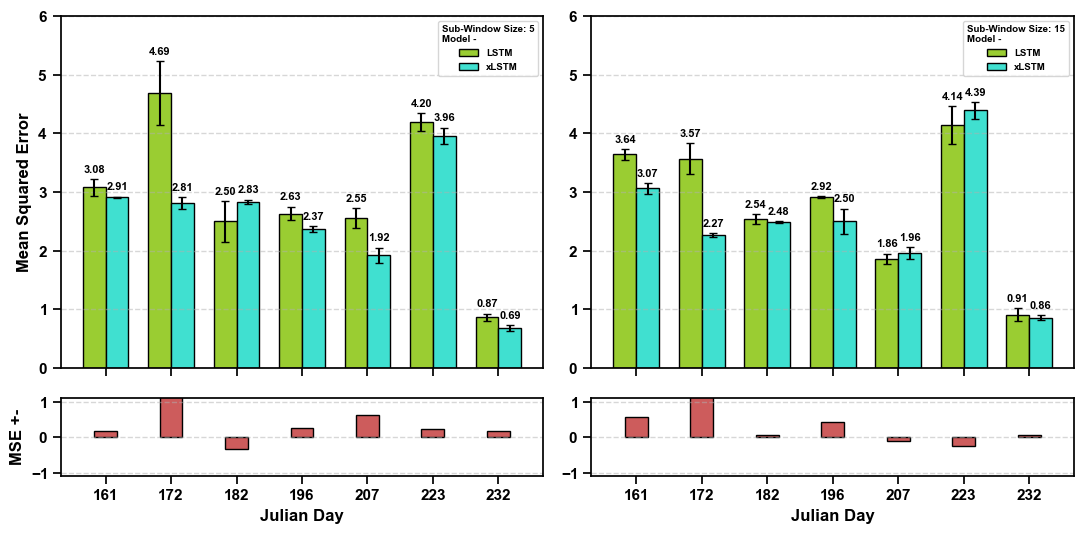

In [105]:
fig, ax = plt.subplots(2, 2, figsize=(11,5.5), sharex=True, sharey=False, height_ratios=[0.45, 0.1])

# Example: share y only within the first two rows (left <-> right),
# but leave the third row independent.
for i in range(2-1):
    ax[0,i+1].sharey(ax[0,i])
    ax[1,i+1].sharey(ax[1,i])
    # ax[2,i+1].sharey(ax[2,i])

hue_order = ['LSTM', 'xLSTM']
bar_width = 0.35
cmap = ['yellowgreen', 'turquoise', 'indianred']

# Default Model xLSTM
x_labels = df['Test'].unique()
x_pos = np.arange(len(x_labels))

for i, hue_val in enumerate(hue_order):
    ####################
    subset = df_comp.loc[(hue_val, 5)]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars1 = ax[0,0].bar(
        xpos,
        subset['mean_y'],
        yerr=subset['se_y'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars1):
        height = bar.get_height()
        err = float(subset['se_y'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
        
    ####################
    subset = df_comp.loc[(hue_val, 15)]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars2 = ax[0,1].bar(
        xpos,
        subset['mean_y'],
        yerr=subset['se_y'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars2):
        height = bar.get_height()
        err = float(subset['se_y'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
    ####################
    # subset = df_comp.loc[(hue_val, 30)]
    # offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    # xpos = x_pos + offset
    #
    # bars2 = ax[0,2].bar(
    #     xpos,
    #     subset['mean_y'],
    #     yerr=subset['se_y'],
    #     width=bar_width,
    #     label=hue_val,
    #     color=cmap[i],
    #     capsize=3,
    #     edgecolor='black'
    # )

    # # Annotate bars on top of the error bar caps
    # for j, bar in enumerate(bars2):
    #     height = bar.get_height()
    #     err = float(subset['se_y'].iloc[j])
    #     y = height + err  # place annotation at top of yerr
    #     ax[0,2].annotate(f'{height:.2f}',
    #                 xy=(bar.get_x() + bar.get_width() / 2, y),
    #                 xytext=(0, 3),
    #                 textcoords='offset points',
    #                 ha='center', va='bottom',
    #                 fontsize=8, fontweight='bold')
        
ax[1,0].bar(
    np.arange(len(x_labels)),
    df_comp.loc[('LSTM', 5)]['mean_y'] - df_comp.loc[('xLSTM', 5)]['mean_y'],
    width=bar_width,
    color='indianred',
    edgecolor='black'
)
ax[1,1].bar(
    np.arange(len(x_labels)),
    df_comp.loc[('LSTM', 15)]['mean_y'] - df_comp.loc[('xLSTM', 15)]['mean_y'],
    width=bar_width,
    color='indianred',
    edgecolor='black'
)
# ax[1,2].bar(
#     np.arange(len(x_labels)),
#     df_comp.loc[('LSTM', 30)]['mean_y'] - df_comp.loc[('xLSTM', 30)]['mean_y'],
#     width=bar_width,
#     color='indianred',
#     edgecolor='black'
# )

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1): 
        s = 5 if j == 0 else 15
        s = 30 if j == 2 else s  
        if i < 1:
            axis.legend(title=f"Sub-Window Size: {s}\nModel -", title_fontproperties={'size':7, 'weight':'bold'}, fontsize=7)

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        axis.set_xticks(x_pos)
        axis.set_xticklabels(x_labels)
        axis.set_xlabel('Julian Day') if i == 1 else axis.set_xlabel("")
        if j == 0 and i != 1:
            axis.set_ylabel('Mean Squared Error')
        elif j == 0 and i == 1:
            axis.set_ylabel('MSE +-')
        else:
            axis.set_ylabel("")
        axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)
# ax[0].set_ylabel("Peak Impact Force [kN]");
# ax[0,0].text(0.05, 0.9, "(a)", transform=ax[0,0].transAxes, fontsize=10, fontweight="bold", va='top', ha='left')
# ax[0,1].text(0.05, 0.9, "(b)", transform=ax[0,1].transAxes, fontsize=10, fontweight="bold", va='top', ha='left')
# ax[0,2].text(0.05, 0.9, "(c)", transform=ax[0,2].transAxes, fontsize=10, fontweight="bold", va='top', ha='left')

ax[0,0].set_ylim(0, 6)
ax[1,0].set_ylim(-1.1, 1.1)
fig.tight_layout()
fig.savefig(f"output_images4/model_comp/wo183_larger.png", dpi = 600)

In [106]:
df_comp2 = df.groupby(['Model', 'Interval', 'Test']).agg(
        mean_y=('Hist_WMSE', 'mean'),
        se_y=('Hist_WMSE', lambda v: v.std(ddof=1) / np.sqrt(len(v)))
    )
df_comp2.head()

mean_y      se_y
Model Interval Test                    
LSTM  5        161   0.105200  0.008784
               172   0.185100  0.032093
               182   0.189033  0.006334
               196   0.094333  0.012475
               207   0.190133  0.010138

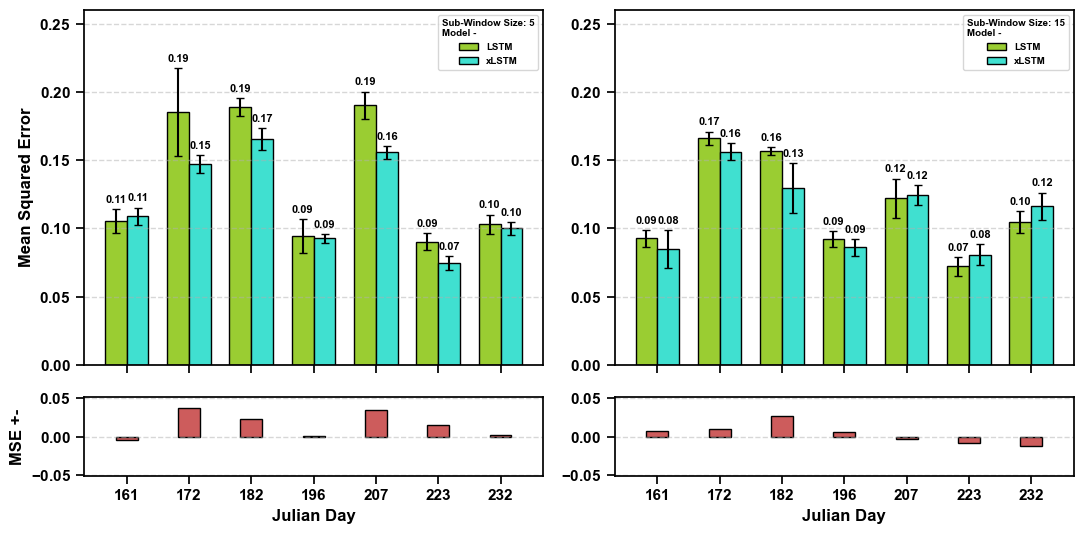

In [107]:
fig, ax = plt.subplots(2, 2, figsize=(11,5.5), sharex=True, sharey=False, height_ratios=[0.45, 0.1])

# Example: share y only within the first two rows (left <-> right),
# but leave the third row independent.
for i in range(2-1):
    ax[0,i+1].sharey(ax[0,i])
    ax[1,i+1].sharey(ax[1,i])
    # ax[2,i+1].sharey(ax[2,i])

hue_order = ['LSTM', 'xLSTM']
bar_width = 0.35
cmap = ['yellowgreen', 'turquoise', 'indianred']

# Default Model xLSTM
x_labels = df['Test'].unique()
x_pos = np.arange(len(x_labels))

for i, hue_val in enumerate(hue_order):
    ####################
    subset = df_comp2.loc[(hue_val, 5)]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars1 = ax[0,0].bar(
        xpos,
        subset['mean_y'],
        yerr=subset['se_y'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars1):
        height = bar.get_height()
        err = float(subset['se_y'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,0].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
        
    ####################
    subset = df_comp2.loc[(hue_val, 15)]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars2 = ax[0,1].bar(
        xpos,
        subset['mean_y'],
        yerr=subset['se_y'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars2):
        height = bar.get_height()
        err = float(subset['se_y'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax[0,1].annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=8, fontweight='bold')
    ####################
    # subset = df_comp2.loc[(hue_val, 30)]
    # offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    # xpos = x_pos + offset

    # bars2 = ax[0,2].bar(
    #     xpos,
    #     subset['mean_y'],
    #     yerr=subset['se_y'],
    #     width=bar_width,
    #     label=hue_val,
    #     color=cmap[i],
    #     capsize=3,
    #     edgecolor='black'
    # )

    # # Annotate bars on top of the error bar caps
    # for j, bar in enumerate(bars2):
    #     height = bar.get_height()
    #     err = float(subset['se_y'].iloc[j])
    #     y = height + err  # place annotation at top of yerr
    #     ax[0,2].annotate(f'{height:.2f}',
    #                 xy=(bar.get_x() + bar.get_width() / 2, y),
    #                 xytext=(0, 3),
    #                 textcoords='offset points',
    #                 ha='center', va='bottom',
    #                 fontsize=8, fontweight='bold')
        
ax[1,0].bar(
    np.arange(len(x_labels)),
    df_comp2.loc[('LSTM', 5)]['mean_y'] - df_comp2.loc[('xLSTM', 5)]['mean_y'],
    width=bar_width,
    color='indianred',
    edgecolor='black'
)
ax[1,1].bar(
    np.arange(len(x_labels)),
    df_comp2.loc[('LSTM', 15)]['mean_y'] - df_comp2.loc[('xLSTM', 15)]['mean_y'],
    width=bar_width,
    color='indianred',
    edgecolor='black'
)
# ax[1,2].bar(
#     np.arange(len(x_labels)),
#     df_comp2.loc[('LSTM', 30)]['mean_y'] - df_comp2.loc[('xLSTM', 30)]['mean_y'],
#     width=bar_width,
#     color='indianred',
#     edgecolor='black'
# )

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1): 
        s = 5 if j == 0 else 15
        s = 30 if j == 2 else s  
        if i < 1:
            axis.legend(title=f"Sub-Window Size: {s}\nModel -", title_fontproperties={'size':7,'weight':'bold'}, fontsize=7)

for i, ax1 in enumerate(ax):
    for j, axis in enumerate(ax1):
        axis.set_xticks(x_pos)
        axis.set_xticklabels(x_labels)
        axis.set_xlabel('Julian Day') if i == 1 else axis.set_xlabel("")
        if j == 0 and i != 1:
            axis.set_ylabel('Mean Squared Error')
        elif j == 0 and i == 1:
            axis.set_ylabel('MSE +-')
        else:
            axis.set_ylabel("")
        axis.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)

# ax[0,0].text(0.05, 0.9, "(a)", transform=ax[0,0].transAxes, fontsize=10, fontweight="bold", va='top', ha='left')
# ax[0,1].text(0.05, 0.9, "(b)", transform=ax[0,1].transAxes, fontsize=10, fontweight="bold", va='top', ha='left')
# ax[0,2].text(0.05, 0.9, "(c)", transform=ax[0,2].transAxes, fontsize=10, fontweight="bold", va='top', ha='left')
ax[0,0].set_ylim(0, 0.26);
ax[1,0].set_ylim(-0.051, 0.051);
fig.tight_layout()
fig.savefig(f"output_images4/model_comp/wo183_Hist_larger.png", dpi = 600)

In [295]:
df_xlstm = df[df['Model'] == 'xLSTM']
df_lstm = df[df['Model'] == 'LSTM']

In [296]:
interval = 5
compile_df = pd.DataFrame(columns=['Test', 't-stat', 'p-val'])
for julday in df_xlstm['Test'].unique():
    diff = df_lstm[(df_lstm['Test'] == julday) & (df_lstm['Interval'] == interval)]['MSE'].to_numpy() - df_xlstm[(df_xlstm['Test'] == julday) & (df_xlstm['Interval'] == interval)]['MSE'].to_numpy()
    print(diff)
    # diff = df_lstm[(df_lstm['Test'] == julday)]['MSE'].to_numpy() - df_xlstm[(df_xlstm['Test'] == julday)]['MSE'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std()/np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
    # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]

[ 0.4666  0.0598 -0.0075]
[0.8198 1.7878 3.0104]
[-0.2604 -0.9238  0.1902]
[0.3074 0.4402 0.049 ]
[0.8355 1.0306 0.0292]
[0.1776 0.2219 0.3224]
[-0.0046  0.331   0.2136]


In [297]:
compile_df

,Test,t-stat,p-val
0,161.0,1.430419,0.288877
1,172.0,3.618746,0.068599
2,182.0,-1.254270,0.336467
3,196.0,2.831525,0.105377
4,207.0,2.524461,0.127570
5,223.0,6.879943,0.020480
6,232.0,2.242090,0.154197


In [298]:
interval = 5
compile_df = pd.DataFrame(columns=['Test', 't-stat', 'p-val'])
for julday in df_xlstm['Test'].unique():
    diff = df_lstm[(df_lstm['Test'] == julday) & (df_lstm['Interval'] == interval)]['Hist_WMSE'].to_numpy() - df_xlstm[(df_xlstm['Test'] == julday) & (df_xlstm['Interval'] == interval)]['Hist_WMSE'].to_numpy()
    print(diff)
    # diff = df_lstm[(df_lstm['Test'] == julday)]['MSE'].to_numpy() - df_xlstm[(df_xlstm['Test'] == julday)]['MSE'].to_numpy()
    mean_diff = diff.mean()
    se_diff = diff.std()/np.sqrt(len(diff))
    t_stat = mean_diff / se_diff
    p_val = stats.t.sf(np.abs(t_stat), len(diff)-1)*2
    # print(f"T-statistic: {t_stat:.3f}, p-value: {p_val:.3f}")
    compile_df.loc[len(compile_df)] = [julday, t_stat, p_val]

[ 0.021 -0.028 -0.004]
[ 0.0223 -0.0099  0.1012]
[0.0323 0.0252 0.013 ]
[-0.0021 -0.0238  0.0308]
[0.0277 0.0462 0.0292]
[0.0313 0.012  0.0041]
[-0.011   0.0001  0.0195]


In [299]:
compile_df

,Test,t-stat,p-val
0,161.0,-0.317454,0.780976
1,172.0,1.405247,0.295146
2,182.0,5.106819,0.036271
3,196.0,0.126036,0.911231
4,207.0,7.094895,0.019293
5,223.0,2.395345,0.138882
6,232.0,0.393929,0.731665


# Model Size Effects

In [58]:
model_configs = ['smaller', 'default', 'larger', 'v_larger']
# base_dir = "../comparison_baseline_tt_5_15_1/average_60_45"
file_name = "model_evaluation/evaluation_output_wo_noise.txt"
# file_name = "model_evaluation/evaluation_output_constrained.txt"
column_names = ['Model','Config','Time_To_Train','Test','Val','Interval','MSE','RMSE','MAE','R2','Corr','PearsonR','Hist-WMSE']
dtypes = [str, str, str, int, int, int, float, float, float, float, float, float, float]
dtype_dict = {k:v for k,v in zip(column_names, dtypes)}
context_len = 5
#########################################################
smoothing=60
divide_by=45
for i in range(1,4):
    base_dir = f"../comparison_baseline_tt_{context_len}_15_{i}"
    df1 = pd.read_csv(f"{base_dir}/average_{smoothing}_{divide_by}/{file_name}", 
                    names=column_names,
                    ).drop(0, axis=0).reset_index(inplace=False, drop=True)
    df1 = df1.astype(dtype_dict)
    df1 = df1[df1.Model == 'xLSTM'].reset_index(inplace=False, drop=True)
    df1 = df1.drop_duplicates(subset=['Model','Config','Test','Interval'],keep='last')
    df1['Repeat'] = [i] * len(df1)
    # df1 = df1[df1.Test != 183]
    if i == 1:
        df = df1.copy()
    else:
        df = pd.concat([df,df1], axis=0)

df.reset_index(inplace=True, drop=True)
# df1['MSE'].astype(float)

In [59]:
df.sample(5)

,Model,Config,Time_To_Train,Test,Val,Interval,MSE,RMSE,MAE,R2,Corr,PearsonR,Hist-WMSE,Repeat
78,xLSTM,v_larger,0:07:49,183,183,15,10.1601,3.1875,2.2906,-0.0115,1.0,0.9545,0.1728,1
23,xLSTM,default,0:18:04,232,232,5,1.3060,1.1428,1.0100,0.9228,-2.0,0.9779,276.8000,1
205,xLSTM,default,0:02:14,223,223,30,6.1010,2.4700,2.2942,0.8168,1.0,0.9794,12.3533,3
218,xLSTM,smaller,0:05:13,207,207,15,3.1875,1.7853,1.1871,0.8707,-2.0,0.9418,0.1383,3
113,xLSTM,default,0:52:57,182,182,5,8.8313,2.9718,1.8971,0.8322,-9.0,0.9256,346.3556,2


In [60]:
xlabels = df1.Test.unique()

compdf = pd.DataFrame(columns=['Config', 'Interval', 'Test', 'MSE_mean', 'MSE_se'])
for config in model_configs:
    for interval in [5, 15, 30]:
        for test in xlabels:
            temp = df[(df.Config == config) & (df.Interval == interval) & (df.Test == test)].agg(
                mean_y=('MSE',np.mean),
                se_y=('MSE',lambda v: v.std(ddof=1) / np.sqrt(len(v)))
            )
            compdf.loc[len(compdf)] = [config, interval, test, temp.loc['mean_y'].item(), temp.loc['se_y'].item()];

/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_28671/3155225639.py:7: FutureWarning: The provided callable <function mean at 0x1110663e0> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  temp = df[(df.Config == config) & (df.Interval == interval) & (df.Test == test)].agg(
/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_28671/3155225639.py:7: FutureWarning: The provided callable <function mean at 0x1110663e0> is currently using Series.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  temp = df[(df.Config == config) & (df.Interval == interval) & (df.Test == test)].agg(
/var/folders/9b/f10dy2654w79wqw49pdgt37c0000gp/T/ipykernel_28671/3155225639.py:7: FutureWarning: The provided callable <function mean at 0x1110663e0> is currently using Series.mean. In a future 

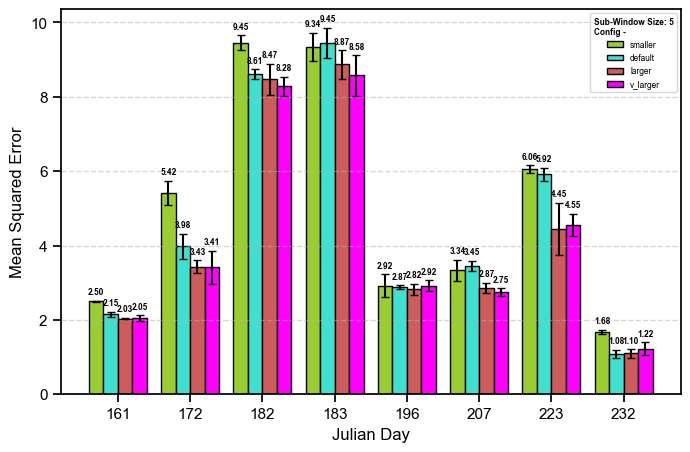

In [61]:
fig, ax = plt.subplots(figsize=(8,5))

hue_order = model_configs
bar_width = 0.20
cmap = ['yellowgreen', 'turquoise', 'indianred', 'magenta']

xlabels = df1.Test.unique()
x_pos = np.arange(1, len(xlabels)+1, 1)

for i, hue_val in enumerate(hue_order):
    subset = compdf[(compdf.Config == hue_val) & (compdf.Interval == 5)]
    offset = (i - len(hue_order) / 2) * bar_width + bar_width / 2
    xpos = x_pos + offset

    bars = ax.bar(
        xpos,
        subset['MSE_mean'],
        yerr=subset['MSE_se'],
        width=bar_width,
        label=hue_val,
        color=cmap[i],
        capsize=3,
        edgecolor='black'
    )

    # Annotate bars on top of the error bar caps
    for j, bar in enumerate(bars):
        height = bar.get_height()
        err = float(subset['MSE_se'].iloc[j])
        y = height + err  # place annotation at top of yerr
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=6, fontweight='bold')
        
# for i, ax1 in enumerate(ax):
#     for j, axis in enumerate(ax1): 
#         s = 5 if j == 0 else 15
#         s = 30 if j == 2 else s  
#         if i < 1:
ax.legend(title=f"Sub-Window Size: 5\nConfig -", title_fontproperties={'size':6,'weight':'bold'}, fontsize=6)

# for i, ax1 in enumerate(ax):
#     for j, axis in enumerate(ax1):
ax.set_xticks(x_pos)
ax.set_xticklabels(xlabels)
ax.set_xlabel('Julian Day') #if i == 1 else ax.set_xlabel("")
# if j == 0 and i != 1:
ax.set_ylabel('Mean Squared Error')
# elif j == 0 and i == 1:
#     ax.set_ylabel('MSE +-')
# else:
#     ax.set_ylabel("")
ax.grid(True, axis='y', which="both", linestyle="--", alpha=0.5)

# Combined Image of Inversion Results

In [4]:
from functions.data_processing.read_data import load_seismic_data, load_label, load_seismic_data_test

plt.rcParams.update({
    'font.size': 7,             # Set global font size
    'font.family': 'Arial',      # Set global font family
    'legend.fontsize': 7,        # Set legend font size
    'figure.figsize': (5.5, 3.5), # Set figure size in inches
    'axes.formatter.limits': (-3, 6),
    'axes.formatter.use_mathtext': True,
    'font.weight': 'bold',
    'axes.labelweight': 'bold'
})
import json
from matplotlib.ticker import ScalarFormatter, MultipleLocator

with open("../config/event_id_map.json", "r") as file:
    event_map = json.load(file)

In [5]:
base_dir = {i:f"../comparison_baseline_cv_5_15_{i}/average_60_45/" for i in range(1,4)}
base_dir
event_ids = ["1", "3", "4", "5", "6", "7", "8", "9"]
juldays = [event_map[i]['julday'] if type(event_map[i]['julday']) is int  else event_map[i]['julday'][0] for i in event_ids]
# globals()[f'dfcomp_{julday}']
interval = 5
config = 'v_larger'
model = "xLSTM"
for i in range(1, 4):
    best_comb = pd.read_csv(f"{base_dir[i]}/model_evaluation/best_combinations.csv")
    best_comb = best_comb[(best_comb['Interval'] == interval) & (best_comb['Config'] == config) & (best_comb['Model'] == model)]
    for julday in (juldays):
        best_comb_per = best_comb[best_comb['Test'] == julday]
        test = best_comb_per['Test'].item()
        val = best_comb_per['Val'].item()
        # print(test, val)
        df_filename = f"{base_dir[i]}/output_df/{config}/{interval}/{model}_t{test}_v{val}.csv"
        temp = pd.read_csv(df_filename)
        if i == 1:
            globals()[f"dfcomp_{julday}"] = temp
        else:
            globals()[f"dfcomp_{julday}"] = pd.merge(left=globals()[f"dfcomp_{julday}"],
                                                    right=temp[['Timestamps','Predicted_Output']],
                                                    on='Timestamps',
                                                    how='left',
                                                    )
            
for julday in juldays:
    globals()[f"dfcomp_{julday}"]['Mean_PO'] = globals()[f"dfcomp_{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].mean(axis=1)
    globals()[f"dfcomp_{julday}"]['Std_PO'] = globals()[f"dfcomp_{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].std(axis=1)

In [27]:
for i, (julday, event_id) in enumerate(zip(juldays, event_ids)):
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
    # load the seismic signal
    st = load_seismic_data(event_id, "ILL11", 2019)
    # load the label
    label = load_label([event_id], "ILL11", 5, "average", trim = True, smoothing = None, divide_by = None)
    d1 = ax.plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11")
    ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%dT%H:%M:%S'))
    ax.set_ylim(-1.5, 1.5);

    ax_t = ax.twinx()
    d2 = ax_t.plot(label.Timestamp.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy(),
                label['Fv [kN]'], color="red", alpha=1, linewidth=0.5, label="Target")
    temp = globals()[f"dfcomp_{julday}"].copy()
    
    times = temp.Timestamps.apply(lambda x: UTCDateTime(x).matplotlib_date).to_numpy()
    mean = temp.Mean_PO.to_numpy()
    std = temp.Std_PO.to_numpy() if 'Std_PO' in temp.columns else np.zeros_like(mean)

    d3 = ax_t.plot(times, mean, color='blue', linewidth=1, label='Model Output')
    ax_t.fill_between(times,
                      mean - std,
                      mean + std,
                      color='turquoise',
                      alpha=0.8,
                      linewidth=0)
    ax_t.set_ylim(-0.2, 40);
    ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax_t.yaxis.set_major_locator(MultipleLocator(10))
    ax_t.yaxis.set_minor_locator(MultipleLocator(5))
    ax_t.tick_params(axis='y', which='major', labelsize=6, length=3)
    ax_t.tick_params(axis='y', which='minor', labelsize=6, length=3)
    ax.set_xlabel(f"Time (UTC+0)", fontweight='bold', fontsize=8)
    ax.set_ylabel("Amplitude (mm/s)", fontweight='bold', fontsize=8)
    ax_t.set_ylabel("Impact Force (kN)", fontweight='bold', fontsize=8)
    lns = d1+d2+d3
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc='upper right')
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))
    ax.tick_params(axis='both', which='major', labelsize=6, length=3)
    ax.tick_params(axis='y', which='minor', labelsize=6, length=3)
    fig.tight_layout()
    fig.savefig(f"./output_images4/training_output/{julday}.png", dpi=600)
    plt.close(fig=fig)

# for axis in ax:
#     axis.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
#     axis.yaxis.set_major_locator(MultipleLocator(1))
#     axis.yaxis.set_minor_locator(MultipleLocator(0.5))
#     axis.tick_params(axis='both', which='major', labelsize=6, length=3)
#     axis.tick_params(axis='y', which='minor', labelsize=6, length=3)
    
# fig.tight_layout()
# fig.savefig("./output_images4/training_output/combined_images.png", dpi=600)

In [7]:
base_dir = "../model_test/ILL11/xLSTM_5"

In [30]:
years = [2020] * 7
juldays = [156, 159, 160, 169, 181, 229, 243]
start_times = ["2020-06-04T15:00:00", "2020-06-07T08:00:00",\
    "2020-06-08T15:00:00",
    "2020-06-17T04:00:00",
    "2020-06-29T05:00:00",
    "2020-08-16T22:00:00",
    "2020-08-30T05:00:00"]
end_times = ["2020-06-04T18:00:00", "2020-06-07T11:00:00",\
    "2020-06-08T20:00:00",
    "2020-06-17T07:00:00",
    "2020-06-29T07:30:00",
    "2020-08-16T23:59:59",
    "2020-08-30T12:00:00"]
station = "ILL11"

# fig, ax = plt.subplots(7, 1, sharey = True, figsize=(7.5,11.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
    st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
    df = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv")
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df = df[df.Timestamps.between(start_time, end_time)]
    d1 = ax.plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11")
    ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d %H:%M'))
    ax.set_ylim(-1, 1);

    ax_t = ax.twinx()
    d2 = ax_t.plot([UTCDateTime(i).matplotlib_date for i in df.Timestamps], df.Predicted_Output_Mean, color='blue', linewidth=1, label='Model Output')
    ax_t.fill_between([UTCDateTime(i).matplotlib_date for i in df.Timestamps],
                      df.Predicted_Output_Min,
                      df.Predicted_Output_Max,
                      color='turquoise',
                      alpha=0.8,
                      linewidth=0)
    ax_t.set_ylim(0, 45)
    ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax_t.yaxis.set_major_locator(MultipleLocator(10))
    ax_t.yaxis.set_minor_locator(MultipleLocator(5))
    ax_t.tick_params(axis='y', which='major', labelsize=6, length=3)
    ax_t.tick_params(axis='y', which='minor', labelsize=6, length=3)
    ax.set_xlabel(f"Time (UTC+0)", fontweight='bold', fontsize=8)
    ax.set_ylabel("Amplitude (mm/s)", fontweight='bold', fontsize=8)
    ax_t.set_ylabel("Impact Force (kN)", fontweight='bold', fontsize=8)
    lns = d1+d2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc='upper right')
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))
    ax.tick_params(axis='both', which='major', labelsize=6, length=3)
    ax.tick_params(axis='y', which='minor', labelsize=6, length=3)

    fig.tight_layout()
    fig.savefig(f"./output_images4/testing_output/2020_{julday}.png", dpi=600)
    plt.close(fig=fig)

In [40]:
years = [2021] * 11
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:30:00", "2021-06-05 09:00:00",
            "2021-06-22 19:30:00", "2021-06-24 14:30:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 14:00:00", "2021-09-19 05:30:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2021-05-11 17:00:00", "2021-05-16 20:00:00", "2021-05-22 02:00:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 17:30:00", "2021-07-06 21:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 17:30:00", "2021-09-19 12:30:00"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

# for idx, j in enumerate([5, 6]):
#     fig, ax = plt.subplots(len(years[idx*j:(idx+1)*(j+1)]), 1, sharey = True, figsize=(7.5,8.5))
#     for i, (year, julday, start_time, end_time) in enumerate(zip(years[idx*j:(idx+1)*(j+1)], juldays[idx*j:(idx+1)*(j+1)], start_times[idx*j:(idx+1)*(j+1)], end_times[idx*j:(idx+1)*(j+1)])):
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))

    if julday == 142:
        st = Stream()
        st += load_seismic_data_test(julday=julday-1, station=station, year=year, component="EHZ", network="9S")
        st += load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
        st.merge(method=1, fill_value='latest', interpolation_samples=0)
        df1 = pd.read_csv(f"{base_dir}/{year}/df/{julday-1}.csv", index_col=False)
        df2 = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv", index_col=False)
        df = pd.concat([df1, df2], ignore_index=True)
    else:
        st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
        df = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv")
        
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
    df = df[df.Timestamps.between(start_time, end_time)]
    d1 = ax.plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11")
    ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d %H:%M'))
    ax.set_ylim(-1, 1);

    ax_t = ax.twinx()
    d2 = ax_t.plot([UTCDateTime(i).matplotlib_date for i in df.Timestamps], df.Predicted_Output_Mean, color='blue', linewidth=1, label='Model Output')
    ax_t.fill_between([UTCDateTime(i).matplotlib_date for i in df.Timestamps],
                    df.Predicted_Output_Min,
                    df.Predicted_Output_Max,
                    color='turquoise',
                    alpha=0.8,
                    linewidth=0)
    ax_t.set_ylim(0, 45)
    ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax_t.yaxis.set_major_locator(MultipleLocator(10))
    ax_t.yaxis.set_minor_locator(MultipleLocator(5))
    ax_t.tick_params(axis='y', which='major', labelsize=6, length=3)
    ax_t.tick_params(axis='y', which='minor', labelsize=6, length=3)
    ax.set_xlabel(f"Time (UTC+0)", fontweight='bold', fontsize=8)
    ax.set_ylabel("Amplitude (mm/s)", fontweight='bold', fontsize=8)
    ax_t.set_ylabel("Impact Force (kN)", fontweight='bold', fontsize=8)
    lns = d1+d2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc='upper right')
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))
    ax.tick_params(axis='both', which='major', labelsize=6, length=3)
    ax.tick_params(axis='y', which='minor', labelsize=6, length=3)

    fig.tight_layout()
    fig.savefig(f"./output_images4/testing_output/2021_{julday}.png", dpi=600)
    plt.close(fig=fig)

In [33]:
years = [2022] * 2
juldays = [156, 185]
start_times = ["2022-06-05 10:30:00", "2022-07-04 21:00:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2022-06-05 13:30:00", "2022-07-04 23:59:59"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

# fig, ax = plt.subplots(2, 1, sharey = True, figsize=(7.5,3.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
    st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
    df = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv")
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
    df = df[df.Timestamps.between(start_time, end_time)]
    d1 = ax.plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11")
    ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d %H:%M'))
    ax.set_ylim(-1, 1);

    ax_t = ax.twinx()
    d2 = ax_t.plot([UTCDateTime(i).matplotlib_date for i in df.Timestamps], df.Predicted_Output_Mean, color='blue', linewidth=1, label='Model Output')
    ax_t.fill_between([UTCDateTime(i).matplotlib_date for i in df.Timestamps],
                      df.Predicted_Output_Min,
                      df.Predicted_Output_Max,
                      color='turquoise',
                      alpha=0.8,
                      linewidth=0)
    ax_t.set_ylim(0, 45)
    ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax_t.yaxis.set_major_locator(MultipleLocator(10))
    ax_t.yaxis.set_minor_locator(MultipleLocator(5))
    ax_t.tick_params(axis='y', which='major', labelsize=6, length=3)
    ax_t.tick_params(axis='y', which='minor', labelsize=6, length=3)
    ax.set_xlabel(f"Time (UTC+0)", fontweight='bold', fontsize=8)
    ax.set_ylabel("Amplitude (mm/s)", fontweight='bold', fontsize=8)
    ax_t.set_ylabel("Impact Force (kN)", fontweight='bold', fontsize=8)
    lns = d1+d2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc='upper right')

    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))
    ax.tick_params(axis='both', which='major', labelsize=6, length=3)
    ax.tick_params(axis='y', which='minor', labelsize=6, length=3)

    fig.tight_layout()
    fig.savefig(f"./output_images4/testing_output/2022_{julday}.png", dpi=600)
    plt.close(fig=fig)

In [35]:
years = [2023] * 3
juldays = [153, 161, 193]
start_times = ["2023-06-02 17:00:00", "2023-06-10 05:00:00", "2023-07-12 03:00:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2023-06-02 21:00:00", "2023-06-10 09:00:00", "2023-07-12 06:00:00"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
    st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
    df = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv")
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
    df = df[df.Timestamps.between(start_time, end_time)]
    d1 = ax.plot(st[0].times('matplotlib'), st[0].data, color="black", linewidth=1, alpha=0.75, label="ILL11")
    ax.set_xlim(st[0].times('matplotlib')[0], st[0].times('matplotlib')[-1])
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m-%d %H:%M'))
    ax.set_ylim(-1, 1);

    ax_t = ax.twinx()
    d2 = ax_t.plot([UTCDateTime(i).matplotlib_date for i in df.Timestamps], df.Predicted_Output_Mean, color='blue', linewidth=1, label='Model Output')
    ax_t.fill_between([UTCDateTime(i).matplotlib_date for i in df.Timestamps],
                      df.Predicted_Output_Min,
                      df.Predicted_Output_Max,
                      color='turquoise',
                      alpha=0.8,
                      linewidth=0)
    ax_t.set_ylim(0, 45)
    ax_t.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax_t.yaxis.set_major_locator(MultipleLocator(10))
    ax_t.yaxis.set_minor_locator(MultipleLocator(5))
    ax_t.tick_params(axis='y', which='major', labelsize=6, length=3)
    ax_t.tick_params(axis='y', which='minor', labelsize=6, length=3)
    ax.set_xlabel(f"Time (UTC+0)", fontweight='bold', fontsize=8)
    ax.set_ylabel("Amplitude (mm/s)", fontweight='bold', fontsize=8)
    ax_t.set_ylabel("Impact Force (kN)", fontweight='bold', fontsize=8)
    lns = d1+d2
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc='upper right')

    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_locator(MultipleLocator(1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.5))
    ax.tick_params(axis='both', which='major', labelsize=6, length=3)
    ax.tick_params(axis='y', which='minor', labelsize=6, length=3)

    fig.tight_layout()
    fig.savefig(f"./output_images4/testing_output/2023_{julday}.png", dpi=600)
    plt.close(fig=fig)

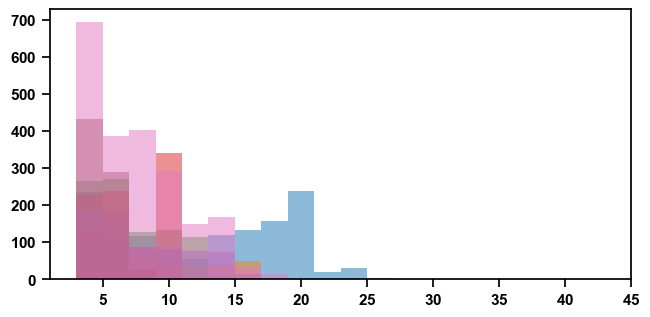

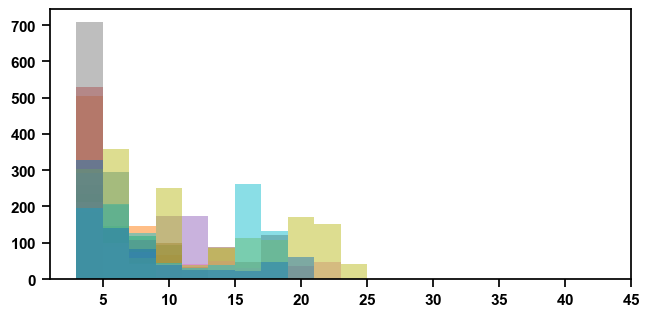

In [24]:
years = [2020] * 7
juldays = [156, 159, 160, 169, 181, 229, 243]
start_times = ["2020-06-04T15:00:00", "2020-06-07T08:00:00",\
    "2020-06-08T15:00:00",
    "2020-06-17T04:00:00",
    "2020-06-29T05:00:00",
    "2020-08-16T22:00:00",
    "2020-08-30T05:00:00"]
end_times = ["2020-06-04T18:00:00", "2020-06-07T11:00:00",\
    "2020-06-08T20:00:00",
    "2020-06-17T07:00:00",
    "2020-06-29T07:30:00",
    "2020-08-16T23:59:59",
    "2020-08-30T12:00:00"]
station = "ILL11"

# fig, ax = plt.subplots(7, 1, sharey = True, figsize=(7.5,11.5))
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
    df = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv")
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df = df[df.Timestamps.between(start_time, end_time)]
    if i == 0:
        bin_heights1, bin_widths1, _ = ax.hist(df.Predicted_Output_Mean, bins=np.arange(3,45,2), alpha=0.5, density=False)
    else:
        b, w, _ = ax.hist(df.Predicted_Output_Mean, bins=np.arange(3,45,2), alpha=0.5, density=False)
        bin_heights1 += b

years = [2021] * 11
juldays = [131, 136, 142, 156, 173, 175, 187, 194, 197, 219, 262]
start_times = ["2021-05-11 13:30:00", "2021-05-16 15:30:00", "2021-05-21 22:30:00", "2021-06-05 09:00:00",
            "2021-06-22 19:30:00", "2021-06-24 14:30:00", "2021-07-06 18:30:00", "2021-07-13 15:00:00",
            "2021-07-16 03:00:00", "2021-08-07 14:00:00", "2021-09-19 05:30:00"]
start_times = [UTCDateTime(x) for x in start_times]
end_times = ["2021-05-11 17:00:00", "2021-05-16 20:00:00", "2021-05-22 02:00:00", "2021-06-05 13:00:00",
            "2021-06-22 22:30:00", "2021-06-24 17:30:00", "2021-07-06 21:00:00", "2021-07-13 20:00:00",
            "2021-07-16 08:00:00", "2021-08-07 17:30:00", "2021-09-19 12:30:00"]
end_times = [UTCDateTime(x) for x in end_times]
station = "ILL11"

# for idx, j in enumerate([5, 6]):
#     fig, ax = plt.subplots(len(years[idx*j:(idx+1)*(j+1)]), 1, sharey = True, figsize=(7.5,8.5))
#     for i, (year, julday, start_time, end_time) in enumerate(zip(years[idx*j:(idx+1)*(j+1)], juldays[idx*j:(idx+1)*(j+1)], start_times[idx*j:(idx+1)*(j+1)], end_times[idx*j:(idx+1)*(j+1)])):
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
for i, (year, julday, start_time, end_time) in enumerate(zip(years, juldays, start_times, end_times)):
    
    if julday == 142:
        st = Stream()
        st += load_seismic_data_test(julday=julday-1, station=station, year=year, component="EHZ", network="9S")
        st += load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
        st.merge(method=1, fill_value='latest', interpolation_samples=0)
        df1 = pd.read_csv(f"{base_dir}/{year}/df/{julday-1}.csv", index_col=False)
        df2 = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv", index_col=False)
        df = pd.concat([df1, df2], ignore_index=True)
    else:
        st = load_seismic_data_test(julday=julday, station=station, year=year, component="EHZ", network="9S")
        df = pd.read_csv(f"{base_dir}/{year}/df/{julday}.csv")
        
    st.trim(starttime=UTCDateTime(start_time), endtime=UTCDateTime(end_time))
    df['Timestamps'] = df['Timestamps'].apply(lambda x: UTCDateTime(x))
    df = df[df.Timestamps.between(start_time, end_time)]
    if i == 0:
        bin_heights2, bin_widths2, _ = ax.hist(df.Predicted_Output_Mean, bins=np.arange(3,45,2), alpha=0.5, density=False)
    else:
        b, w, _ = ax.hist(df.Predicted_Output_Mean, bins=np.arange(3,45,2), alpha=0.5, density=False)
        bin_heights2 += b

<BarContainer object of 20 artists>

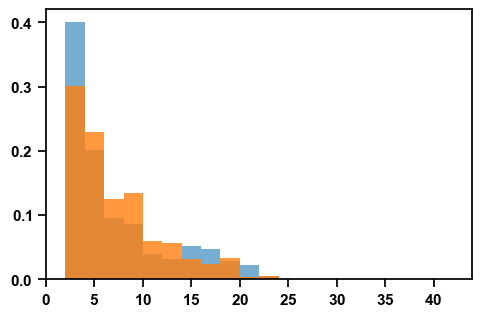

In [37]:
widths1 = [bin_widths1[i+1] - bin_widths1[i] for i in range(len(bin_widths1)-1)]
widths2 = [bin_widths2[i+1] - bin_widths2[i] for i in range(len(bin_widths2)-1)]
plt.bar(bin_widths2[:-1], bin_heights2 / np.sum(bin_heights2), width=widths2, alpha=0.6)
plt.bar(bin_widths1[:-1], bin_heights1 / np.sum(bin_heights1), width=widths1, alpha=0.8)
# plt.xscale('log')
# plt.yscale('log')

# Distributions

In [41]:
from functions.data_processing.read_data import load_seismic_data, load_label, load_seismic_data_test

plt.rcParams.update( {'font.size':7,
                      'axes.formatter.limits': (-3, 6),
                      'axes.formatter.use_mathtext': True} )
import json
from matplotlib.ticker import ScalarFormatter, MultipleLocator

with open("../config/event_id_map.json", "r") as file:
    event_map = json.load(file)

In [43]:
base_dir = {i:f"../comparison_baseline_cv_5_15_{i}/average_60_45/" for i in range(1,4)}
base_dir
event_ids = ["1", "3", "4", "5", "6", "7", "8", "9"]
juldays = [event_map[i]['julday'] if type(event_map[i]['julday']) is int  else event_map[i]['julday'][0] for i in event_ids]
# globals()[f'dfcomp_{julday}']
interval = 5
config = 'v_larger'
model = "xLSTM"
for i in range(1, 4):
    best_comb = pd.read_csv(f"{base_dir[i]}/model_evaluation/best_combinations.csv")
    best_comb = best_comb[(best_comb['Interval'] == interval) & (best_comb['Config'] == config) & (best_comb['Model'] == model)]
    for julday in (juldays):
        best_comb_per = best_comb[best_comb['Test'] == julday]
        test = best_comb_per['Test'].item()
        val = best_comb_per['Val'].item()
        # print(test, val)
        df_filename = f"{base_dir[i]}/output_df/{config}/{interval}/{model}_t{test}_v{val}.csv"
        temp = pd.read_csv(df_filename)
        if i == 1:
            globals()[f"dfcomp_{julday}"] = temp
        else:
            globals()[f"dfcomp_{julday}"] = pd.merge(left=globals()[f"dfcomp_{julday}"],
                                                    right=temp[['Timestamps','Predicted_Output']],
                                                    on='Timestamps',
                                                    how='left',
                                                    )
            
for julday in juldays:
    globals()[f"dfcomp_{julday}"]['Mean_PO'] = globals()[f"dfcomp_{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].mean(axis=1)
    globals()[f"dfcomp_{julday}"]['Std_PO'] = globals()[f"dfcomp_{julday}"][['Predicted_Output_x', 'Predicted_Output_y', 'Predicted_Output']].std(axis=1)

In [ ]:
labels = {i:load_label([i], "ILL11", 5, "average", trim = True, smoothing = None, divide_by = None) for i in ["1", "3", "4", "5", "6", "7", "8", "9"]}

In [45]:
def fit_and_plot_pl(ax, bin_heights, bin_edges, color):
    bin_widths = np.diff(bin_edges)
    bin_centers = bin_edges[:-1] + bin_widths / 2
    density = bin_heights / bin_widths
    mask = (density > 0) & (bin_centers > 0)
    xs = bin_centers[mask]
    ys = density[mask]
    # xs = xs[:-2]
    # ys = ys[:-2]
    # 1) simple log-log linear fit (fast, robust)
    log_a, log_b = np.polyfit(np.log10(xs), np.log10(ys), 1)
    # slope = log_a, intercept = log_b  -> ys ≈ 10^log_b * xs^(log_a)
    alpha_lin = -log_a
    A_lin = 10**log_b
    try:
        p0 = [A_lin, alpha_lin]
        popt, pcov = opt.curve_fit(pl, xs, ys, p0=[A_lin, 0.5], bounds=([0, 0.1], [np.inf, 2.0]), maxfev=5000)
        A_nl, alpha_nl = popt
    except Exception:
        print("In the exception, could not fit power law")
        A_nl, alpha_nl = A_lin, alpha_lin
    x_fit = np.linspace(xs.min(), xs.max(), 200)
    ax.plot(x_fit, pl(x_fit, A_nl, alpha_nl) * bin_widths.mean(), color=color, linestyle='--', label=rf'PL fit $\alpha$={alpha_nl:.2f}')
    return None

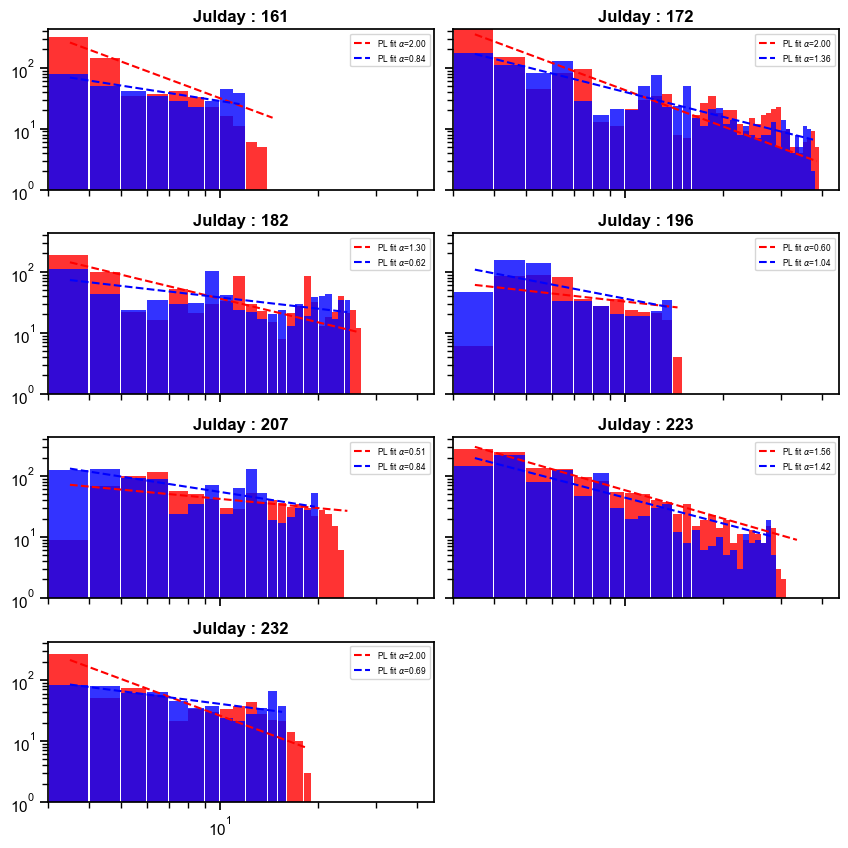

In [98]:
fig, ax = plt.subplots(4,2, sharex=True, sharey=True, figsize=(8.5, 8.5))

for idx, i in enumerate(["1", "3", "4", "6", "7", "8", "9"]):
    label = labels[i]
    julday = event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0]
    
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(label["Fv [kN]"], bins=np.arange(3,45,1), rwidth=0.97, density=False, alpha=0.8, color="red", log=True)
    fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "red")
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(globals()[f"dfcomp_{julday}"].Mean_PO, bins=np.arange(3,45,1), rwidth=0.97, density=False, alpha=0.8, color="blue", log=True);
    fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "blue")
    ax[idx//2, idx%2].set_xscale('log'); ax[idx//2, idx%2].set_xlim(3,45);
    ax[idx//2, idx%2].set_yscale('log'); ax[idx//2, idx%2].set_ylim(bottom=1);
    ax[idx//2, idx%2].set_title(f"Julday : {julday}", fontweight="bold")
    ax[idx//2, idx%2].legend(loc="best", fontsize=6)

    
fig.tight_layout()
fig.delaxes(ax[-1, -1])

In [70]:
bin_edges

array([ 3.,  5.,  7.,  9., 11., 13., 15., 17., 19., 21., 23., 25., 27.,
       29., 31., 33., 35., 37., 39., 41., 43.])

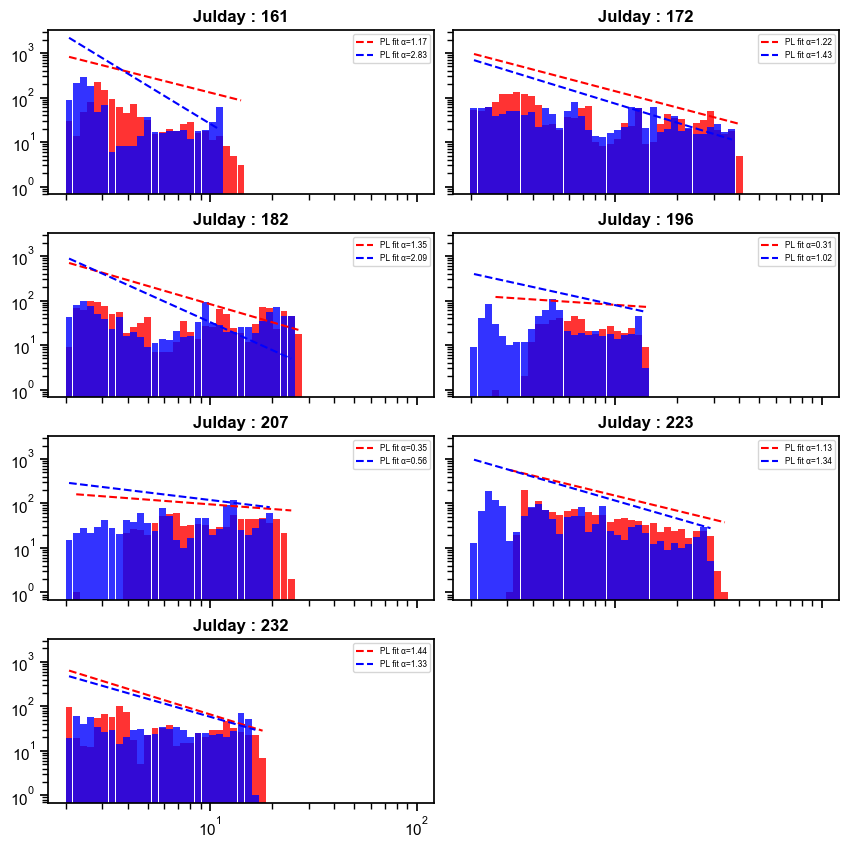

In [79]:
fig, ax = plt.subplots(4,2, sharex=True, sharey=True, figsize=(8.5, 8.5))

for idx, i in enumerate(["1", "3", "4", "6", "7", "8", "9"]):
    label = labels[i]
    julday = event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0]
    
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(label["Fv [kN]"], bins=np.logspace(0.3,2,50), rwidth=0.97, density=False, alpha=0.8, color="red", log=True)
    fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "red")
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(globals()[f"dfcomp_{julday}"].Mean_PO, bins=np.logspace(0.3,2,50), rwidth=0.97, density=False, alpha=0.8, color="blue", log=True);
    fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "blue")
    ax[idx//2, idx%2].set_xscale('log')
    ax[idx//2, idx%2].set_yscale('log')
    ax[idx//2, idx%2].set_title(f"Julday : {julday}", fontweight="bold")
    ax[idx//2, idx%2].legend(loc="best", fontsize=6)
    
fig.tight_layout()
fig.delaxes(ax[-1, -1])

161
172
182
196
207
223
232


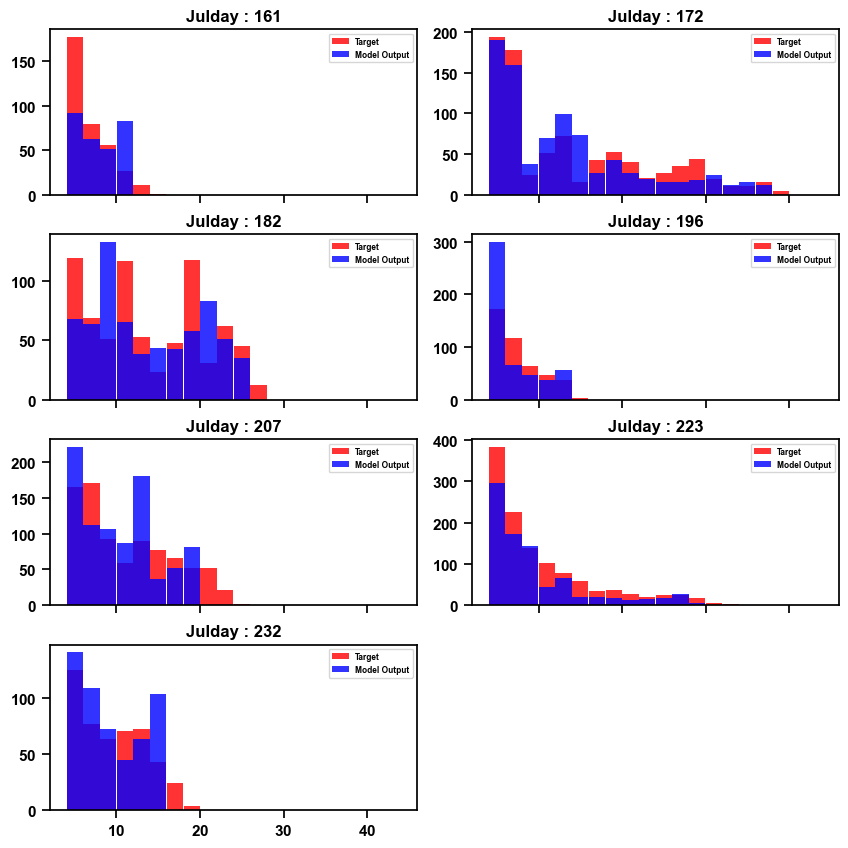

In [ ]:
fig, ax = plt.subplots(4,2, sharex=True, sharey=False, figsize=(8.5, 8.5))

for idx, i in enumerate(["1", "3", "4", "6", "7", "8", "9"]):
    label = labels[i]
    julday = event_map[i]['julday'] if type(event_map[i]['julday']) is int else event_map[i]['julday'][0]
    # print(julday)
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(label["Fv [kN]"], bins=np.arange(4,45,2), rwidth=0.97, density=False, alpha=0.8, color="red", log=False, label="Target")
    # fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "red")
    bin_heights, bin_edges, _ = ax[idx//2, idx%2].hist(globals()[f"dfcomp_{julday}"].Mean_PO, bins=np.arange(4,45,2), rwidth=0.97, density=False, alpha=0.8, color="blue", log=False, label="Model Output");
    # fit_and_plot_pl(ax[idx//2, idx%2], bin_heights, bin_edges, "blue")
    # ax[idx//2, idx%2].set_xscale('log')
    # ax[idx//2, idx%2].set_yscale('log')
    ax[idx//2, idx%2].set_title(f"Julday : {julday}", fontweight="bold")
    ax[idx//2, idx%2].legend(loc="best", fontsize=6)
    
fig.tight_layout()
fig.delaxes(ax[-1, -1])
fig.savefig("./output_images4/results/distributions.png")